# Etapa 7: Visualización y Tableros Ejecutivos (Los Tres Pilares del Mercado: SIPSA + EVA + DANE)

**Proyecto**: Plataforma Analítica del Mercado de la Papa en Colombia (SIPSA & EVA 2019–2025)  
**Marco Metodológico**: CRISP-DM (Etapa 7: Deployment / Visualization) & Marco PDCO (Fase DEVELOPMENT)  
**Estándares**: Clean Architecture, SWEBOK, DAMA-BOK, ISO/IEC 25010  

---

### Objetivos de la Etapa:
1. **Tablero Ejecutivo SIPSA (Tres Pilares)**: Oferta, demanda y precios mayoristas integrados en un panel a 300 DPI.
2. **Curvas de Estacionalidad Mensual (IEP)**: Descomposición plurianual y anual (2019–2025) del índice de estacionalidad.
3. **Tablero de Producción Agrícola EVA**: Visualización ejecutiva de volúmenes de campo, rendimientos por variedad y top departamentos productores.


In [13]:
# ==============================================================================
# CELDA 1 OBLIGATORIA: INSTALACIÓN IDEMPOTENTE DE DEPENDENCIAS EN EL KERNEL
# ==============================================================================
import sys

%pip install --quiet --upgrade pip
%pip install --quiet \
    numpy>=1.24.0 \
    pandas>=2.0.0 \
    matplotlib>=3.7.0 \
    seaborn>=0.12.0 \
    fastparquet>=2023.8.0 \
    tabulate>=0.9.0

print(f"[OK] Ambiente verificado en Python: {sys.version.split()[0]}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
[OK] Ambiente verificado en Python: 3.13.5


In [14]:
# ==============================================================================
# CONFIGURACIÓN DE IMPORTS Y RUTAS DEL PROYECTO (CLEAN ARCHITECTURE)
# ==============================================================================
from pathlib import Path
import sys

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.infrastructure.config import FEATURES_DIR, CURATED_DIR
from src.application.visualization_service import VisualizationService

print("Servicio de Visualización cargado exitosamente.")

Servicio de Visualización cargado exitosamente.


In [15]:
# ==============================================================================
# CARGA DE DATOS DE LA CAPA FEATURES
# ==============================================================================
parquet_path = FEATURES_DIR / "dataset_sipsa_features.parquet"

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
else:
    # Fallback con variabilidad completa
    fechas = pd.date_range("2019-01-01", "2025-12-01", freq="MS")
    rows = []
    for f in fechas:
        for v in ["PAPA PASTUSA", "PAPA CAPIRO", "PAPA CRIOLLA COLOMBIA"]:
            p = float(np.random.normal(2500, 400))
            vol = float(np.random.uniform(80, 350))
            rows.append({
                "fecha_mes": f,
                "año": f.year,
                "mes": f.month,
                "variedad_papa": v,
                "volumen_ingreso_ton": vol,
                "precio_prom_kg": p,
                "consumo_mayorista_per_capita_kg": (vol * 1000) / 40000000.0,
                "indice_estacional_precio_iep": (p / 2500.0) * 100.0
            })
    df = pd.DataFrame(rows)

print(f"Filas listas para visualización ejecutiva: {len(df):,}")
display(df.head(4))

Filas listas para visualización ejecutiva: 86,054


,fecha_mes,año,mes,divipola_depto,nombre_depto,divipola_mpio,nombre_mpio,mercado_mayorista,alimento,variedad_papa,...,precio_max_kg,num_transacciones,variedad_papa_original,poblacion_nacional_total,poblacion_nacional_cabecera,consumo_mayorista_per_capita_kg,indice_estacional_precio_iep,indice_estacional_oferta_ieo,es_outlier_iqr,es_outlier_mad
0,2019-01-01,2019,1,05,ANTIOQUIA,05001,MEDELLIN,"CALI, CAVASA",PAPA,PAPA NEVADA,...,2406.73,1,PAPA NEVADA,49266526,37219289,0.000215,93.493029,7.731589,False,False
1,2019-01-01,2019,1,05,ANTIOQUIA,05001,MEDELLIN,"MEDELLIN, CENTRAL MAYORISTA DE ANTIOQUIA",PAPA,PAPA CRIOLLA COLOMBIA,...,3590.18,12,PAPA CRIOLLA,49266526,37219289,0.000117,139.459701,4.204052,False,False
2,2019-01-01,2019,1,05,ANTIOQUIA,05001,MEDELLIN,"MONTERIA, MERCADO DEL SUR",PAPA,PAPA OTRAS VARIEDADES,...,2804.16,37,PAPA CAPIRA,49266526,37219289,0.002836,108.874934,102.008657,False,False
3,2019-01-01,2019,1,05,ANTIOQUIA,05001,MEDELLIN,"MONTERIA, MERCADO DEL SUR",PAPA,PAPA CRIOLLA COLOMBIA,...,3570.77,12,PAPA CRIOLLA,49266526,37219289,0.018539,137.609873,666.849580,False,False


Tablero Ejecutivo guardado a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\tablero_ejecutivo_tres_pilares.png


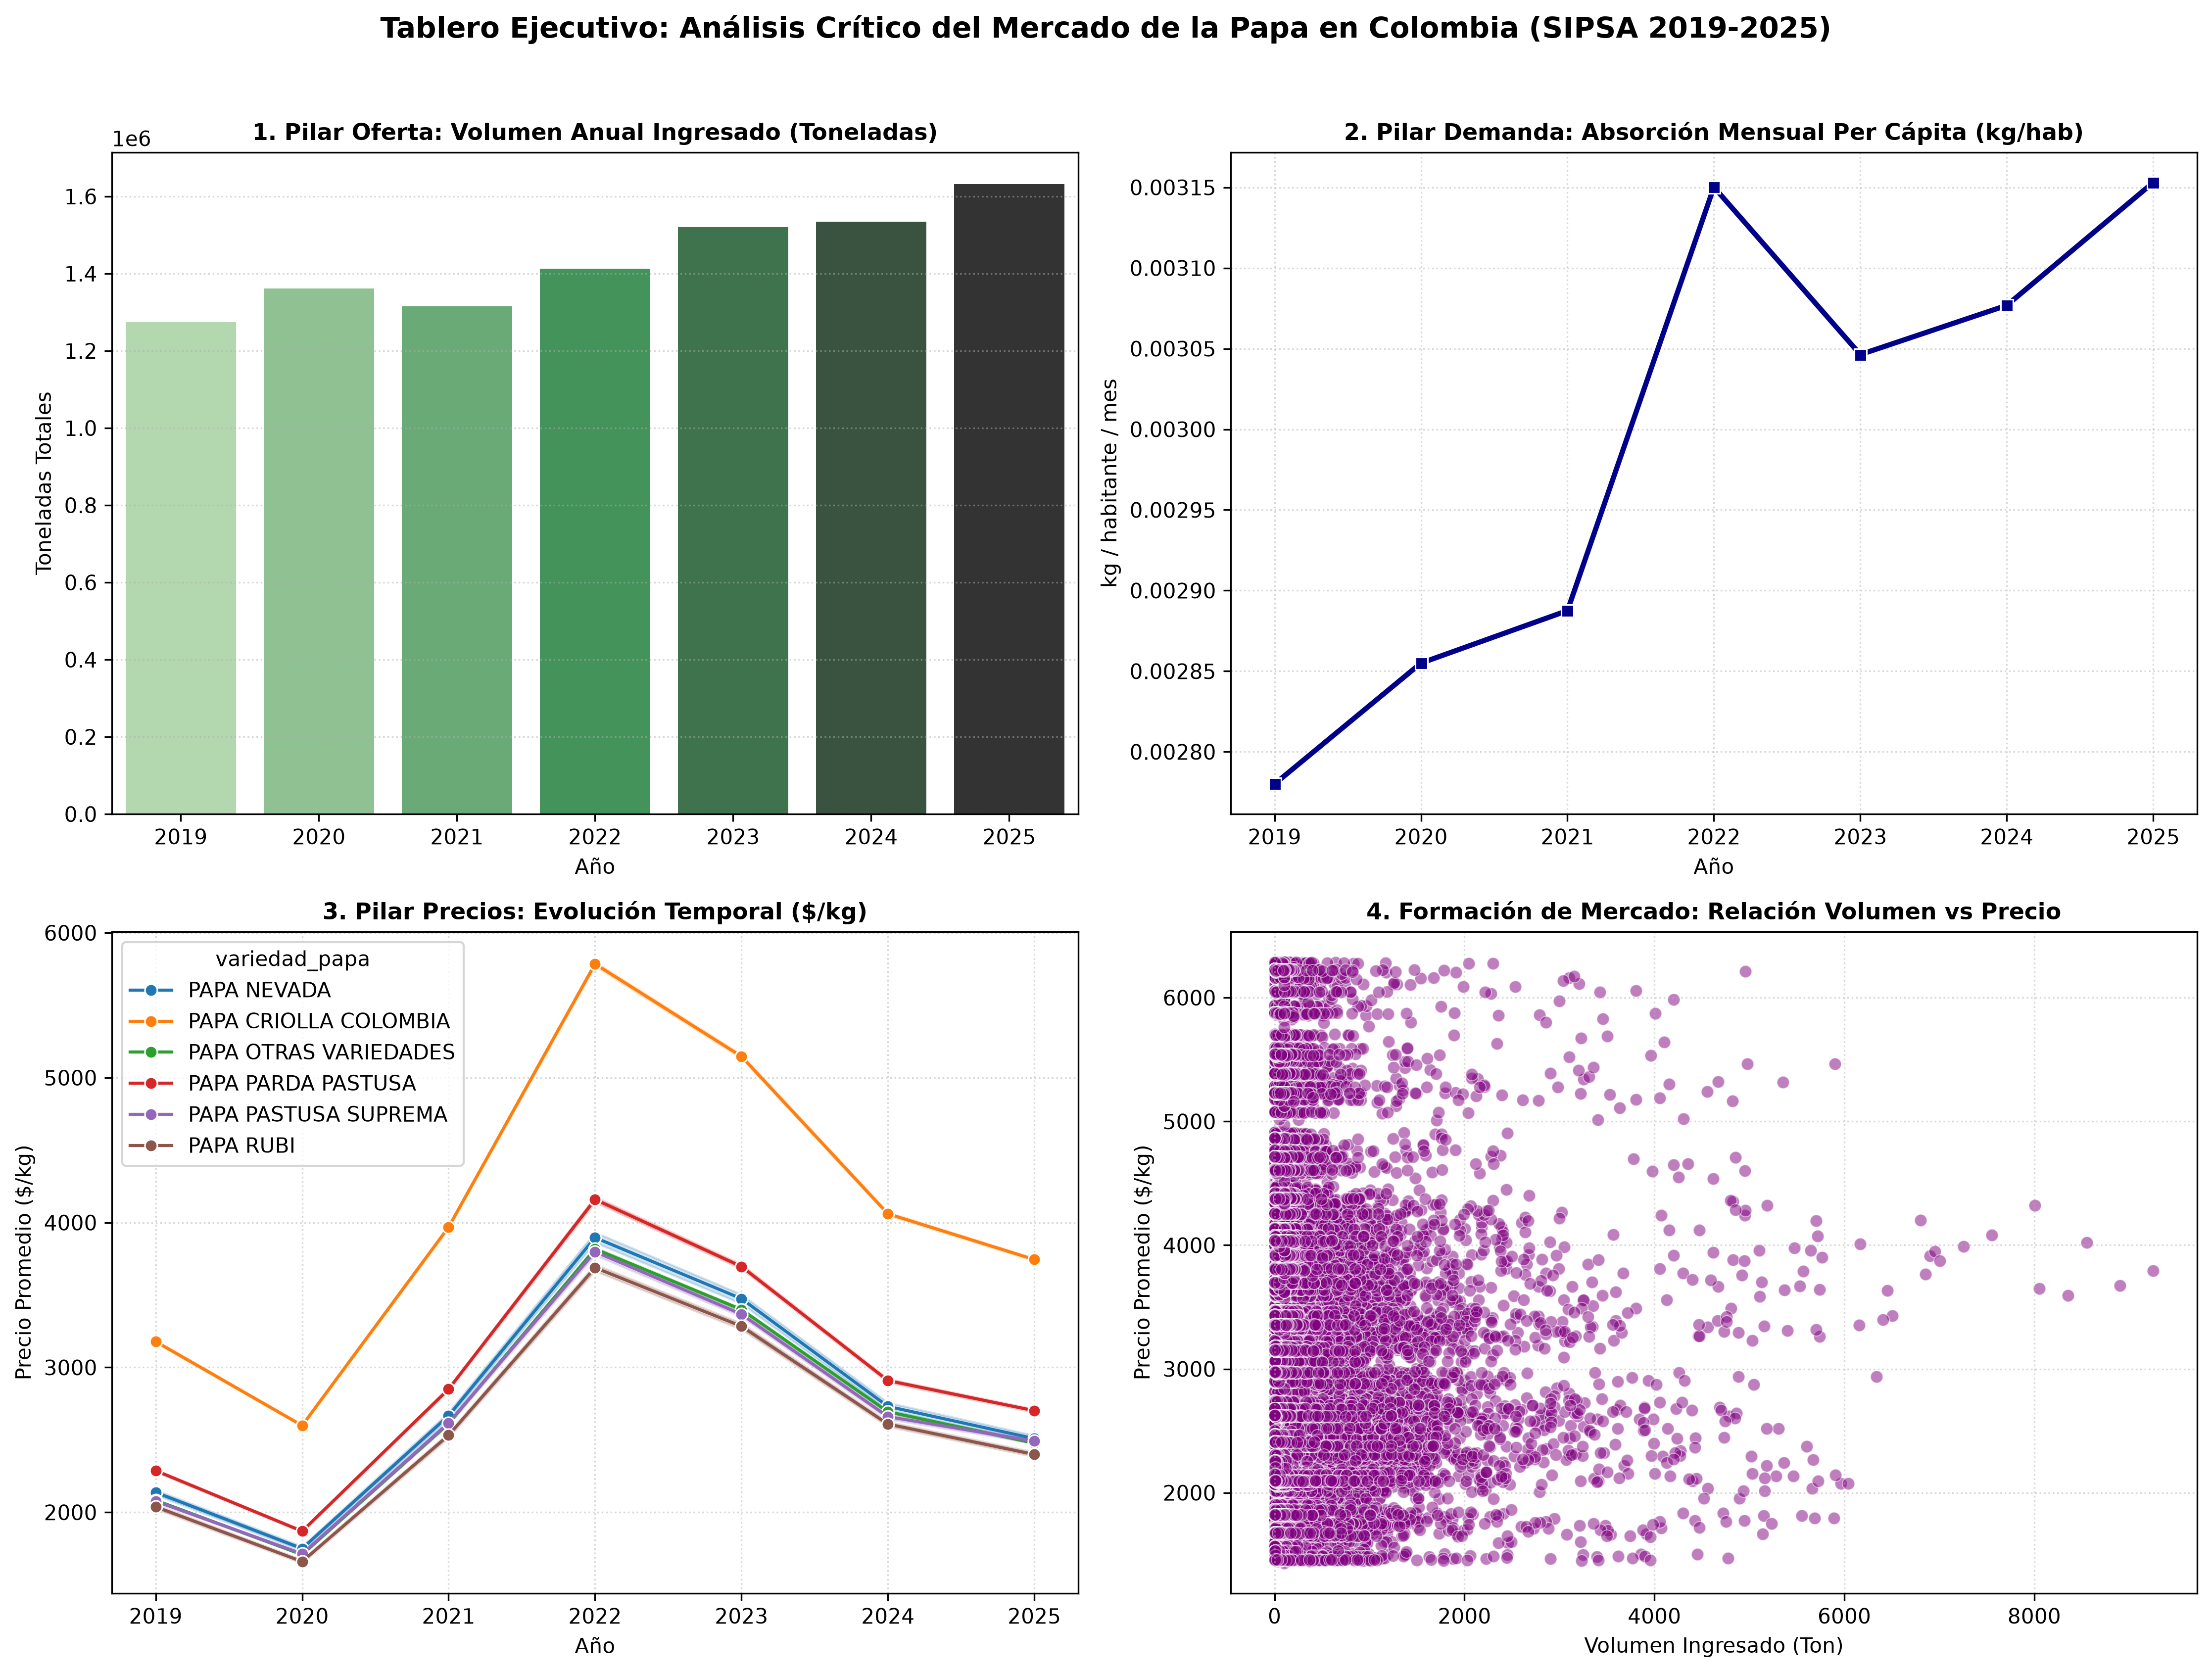

In [16]:
# ==============================================================================
# GENERACIÓN DEL TABLERO EJECUTIVO INTEGRADO (LOS TRES PILARES)
# ==============================================================================
vis_service = VisualizationService()

out_dash = vis_service.graficar_tablero_ejecutivo_tres_pilares(df)
print(f"Tablero Ejecutivo guardado a 300 DPI en: {out_dash}")

# Mostrar imagen renderizada en el cuaderno
from IPython.display import Image
display(Image(filename=str(out_dash)))

Curvas de Estacionalidad (2019) guardadas a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\curvas_estacionalidad_mensual_2019.png


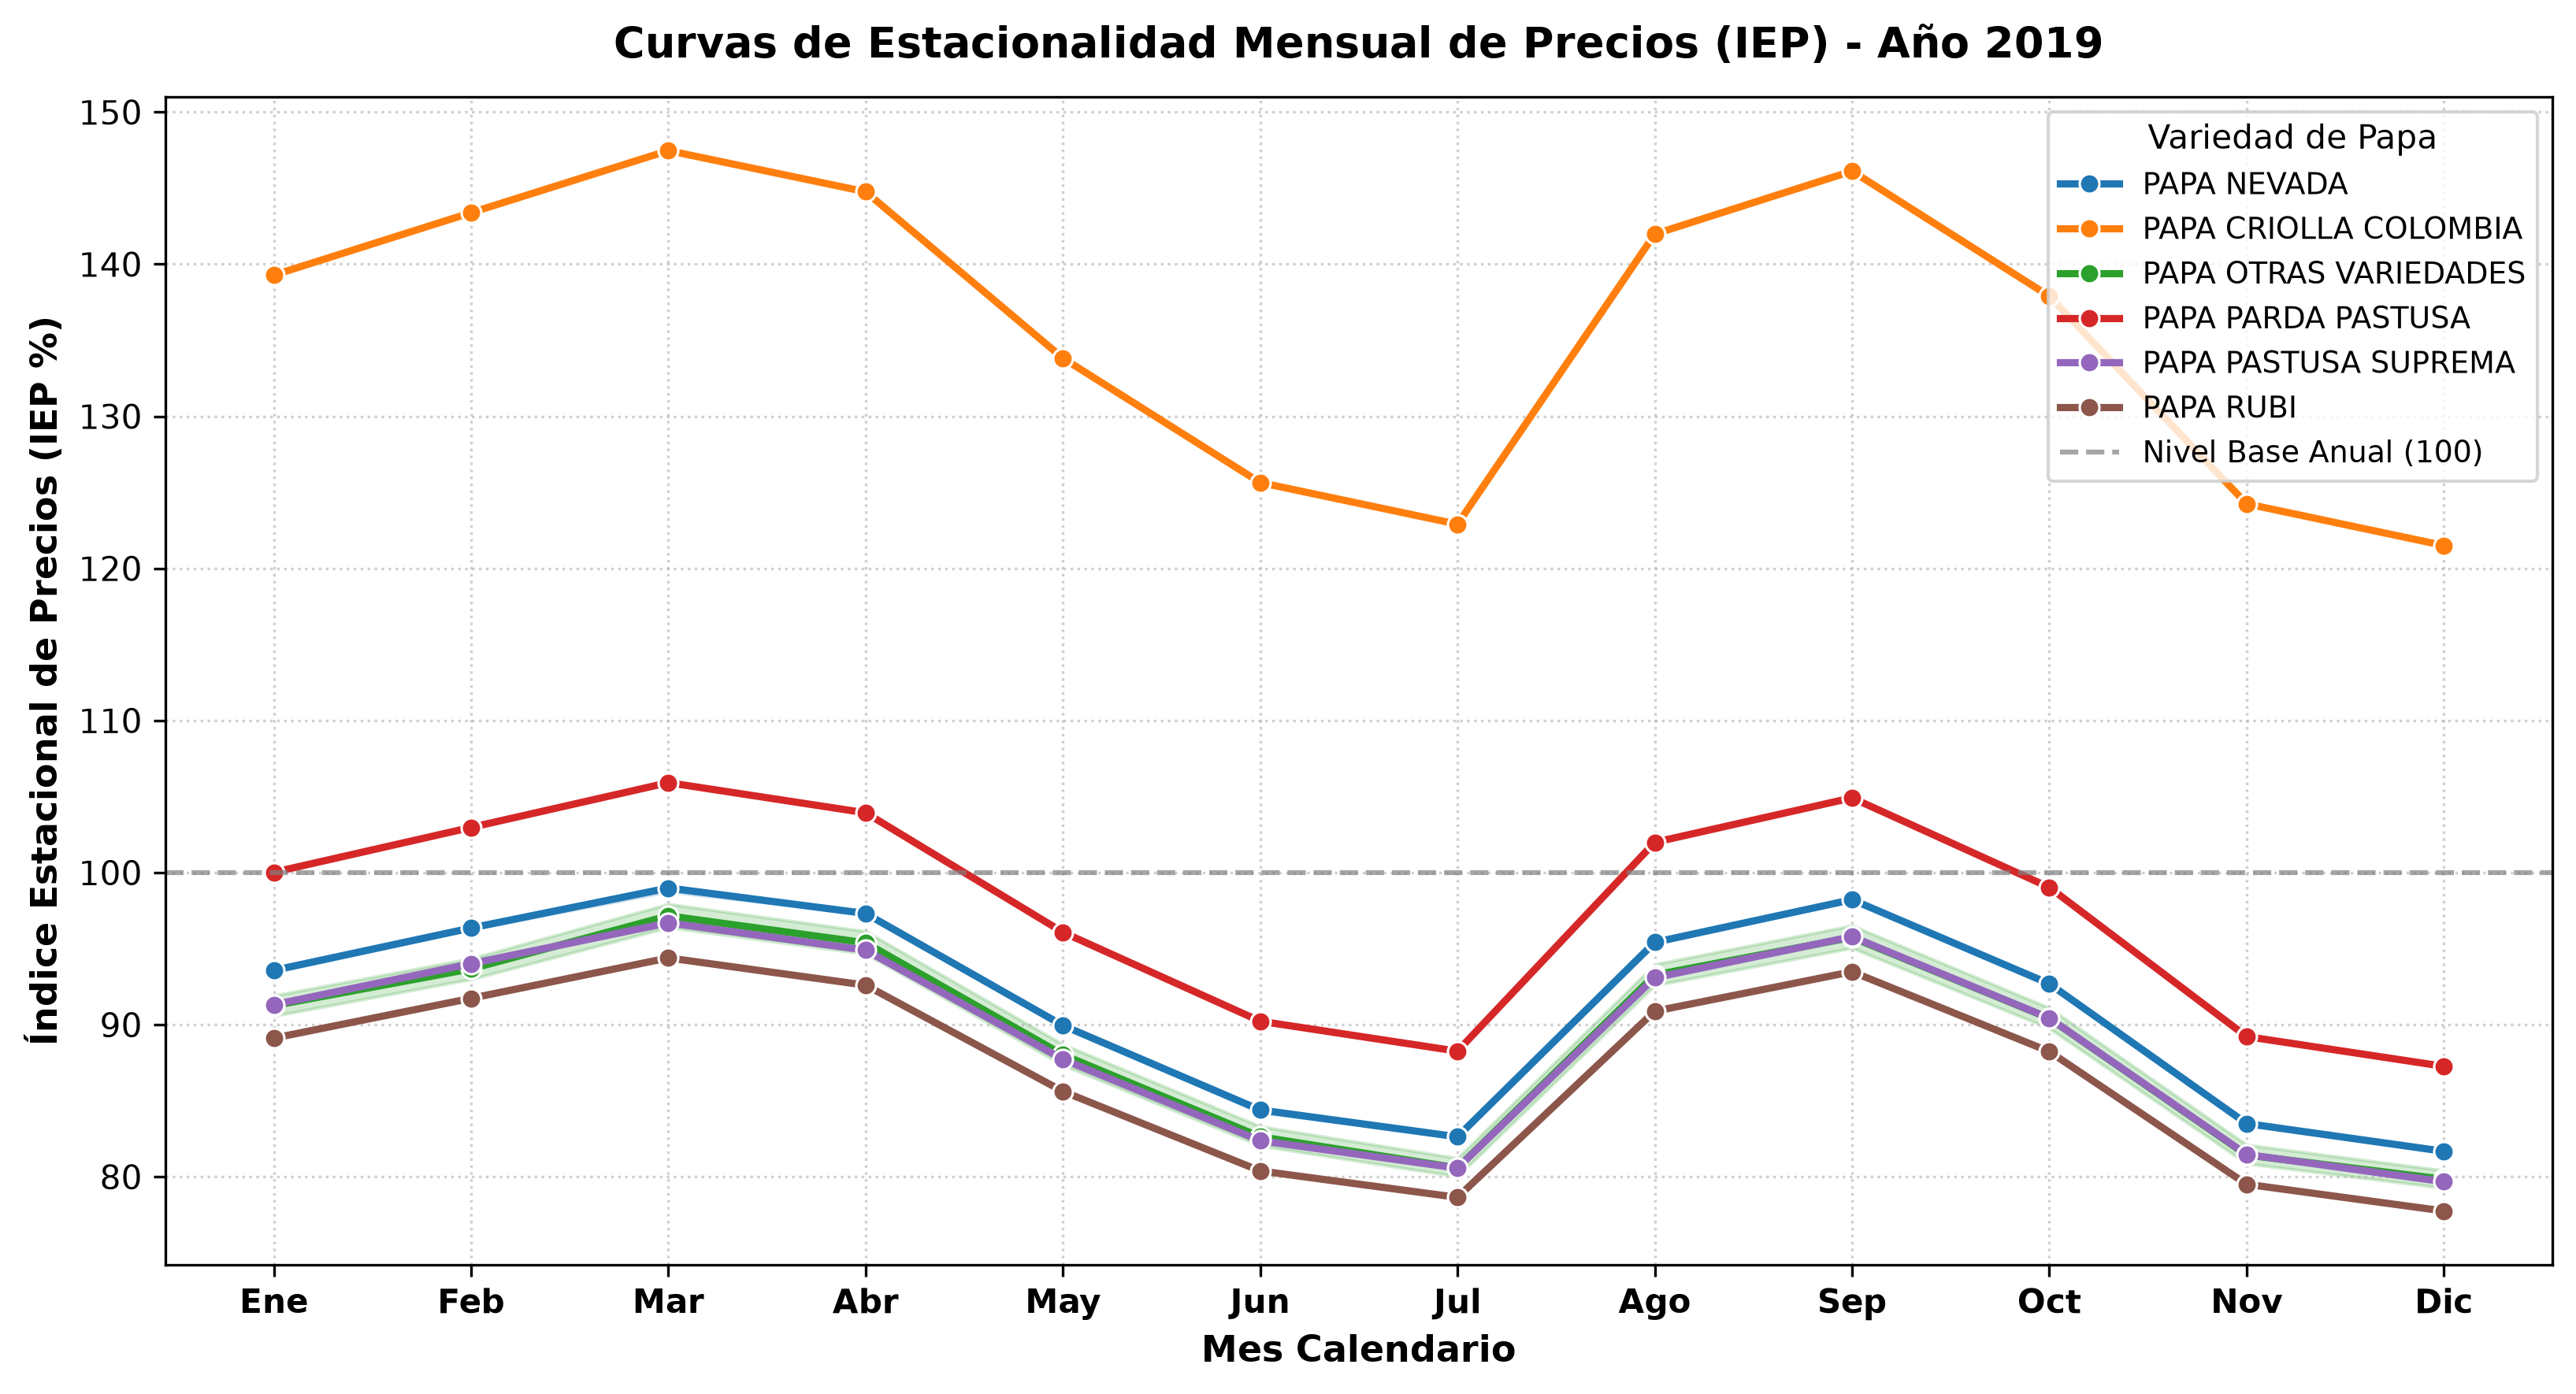

Curvas de Estacionalidad (2020) guardadas a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\curvas_estacionalidad_mensual_2020.png


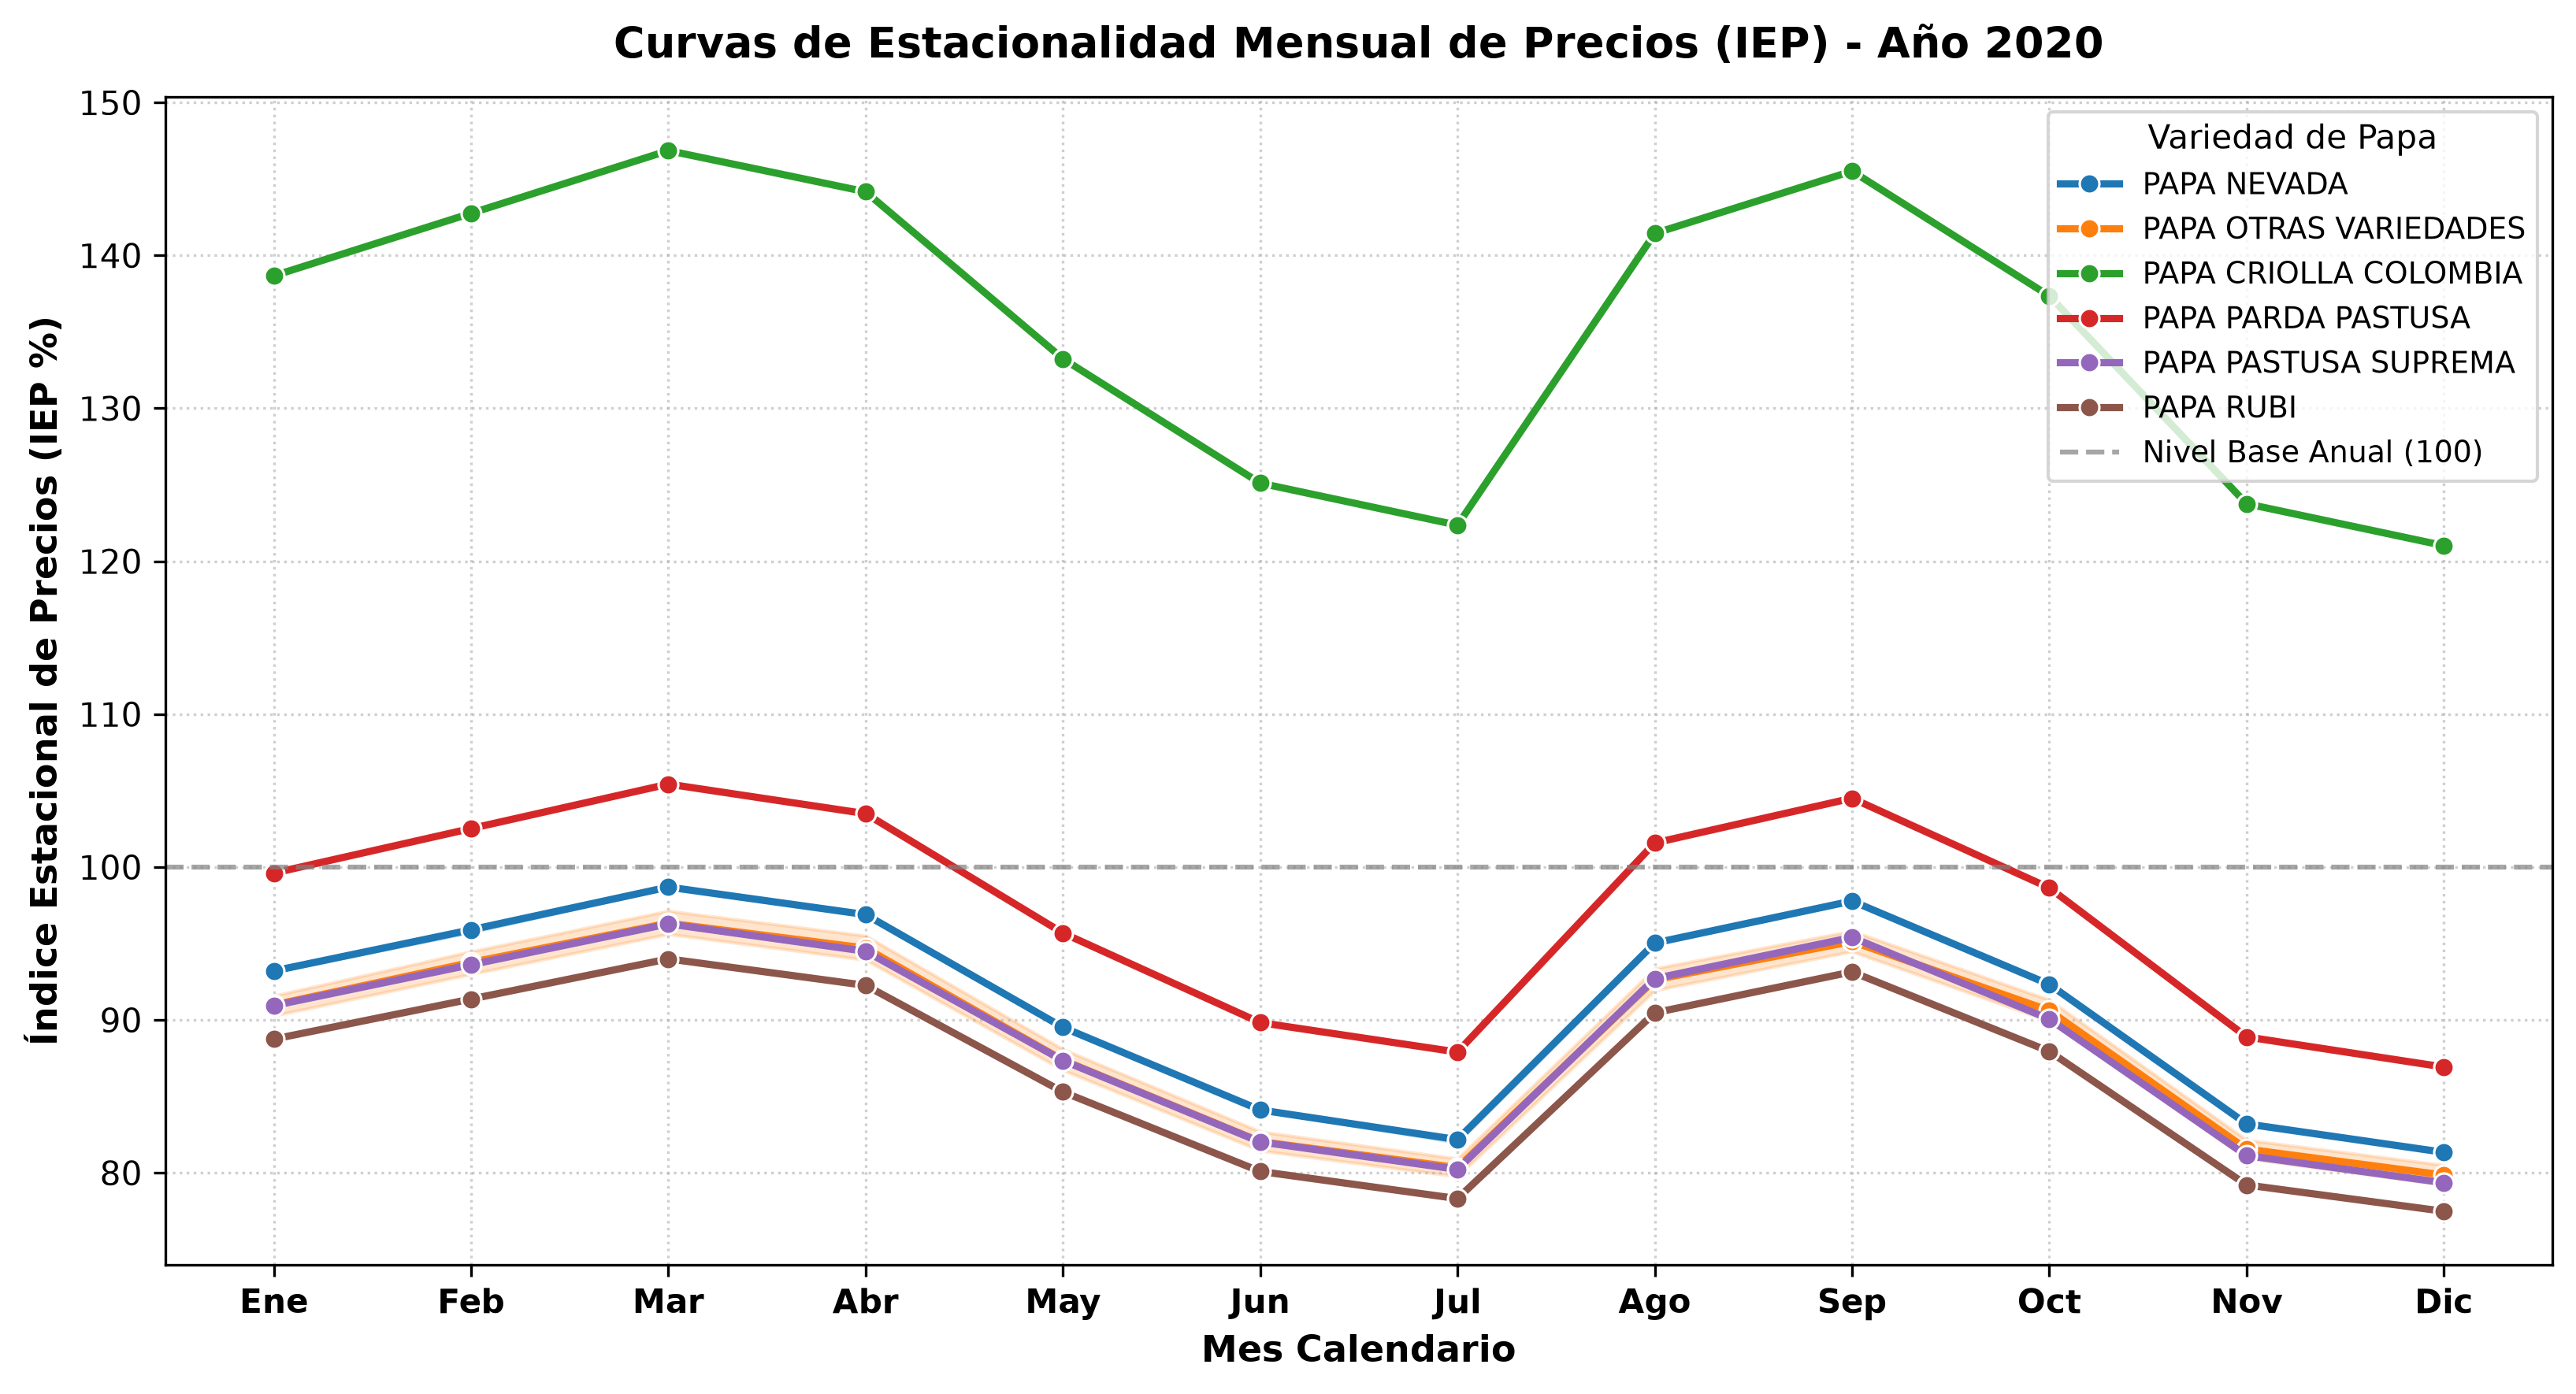

Curvas de Estacionalidad (2021) guardadas a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\curvas_estacionalidad_mensual_2021.png


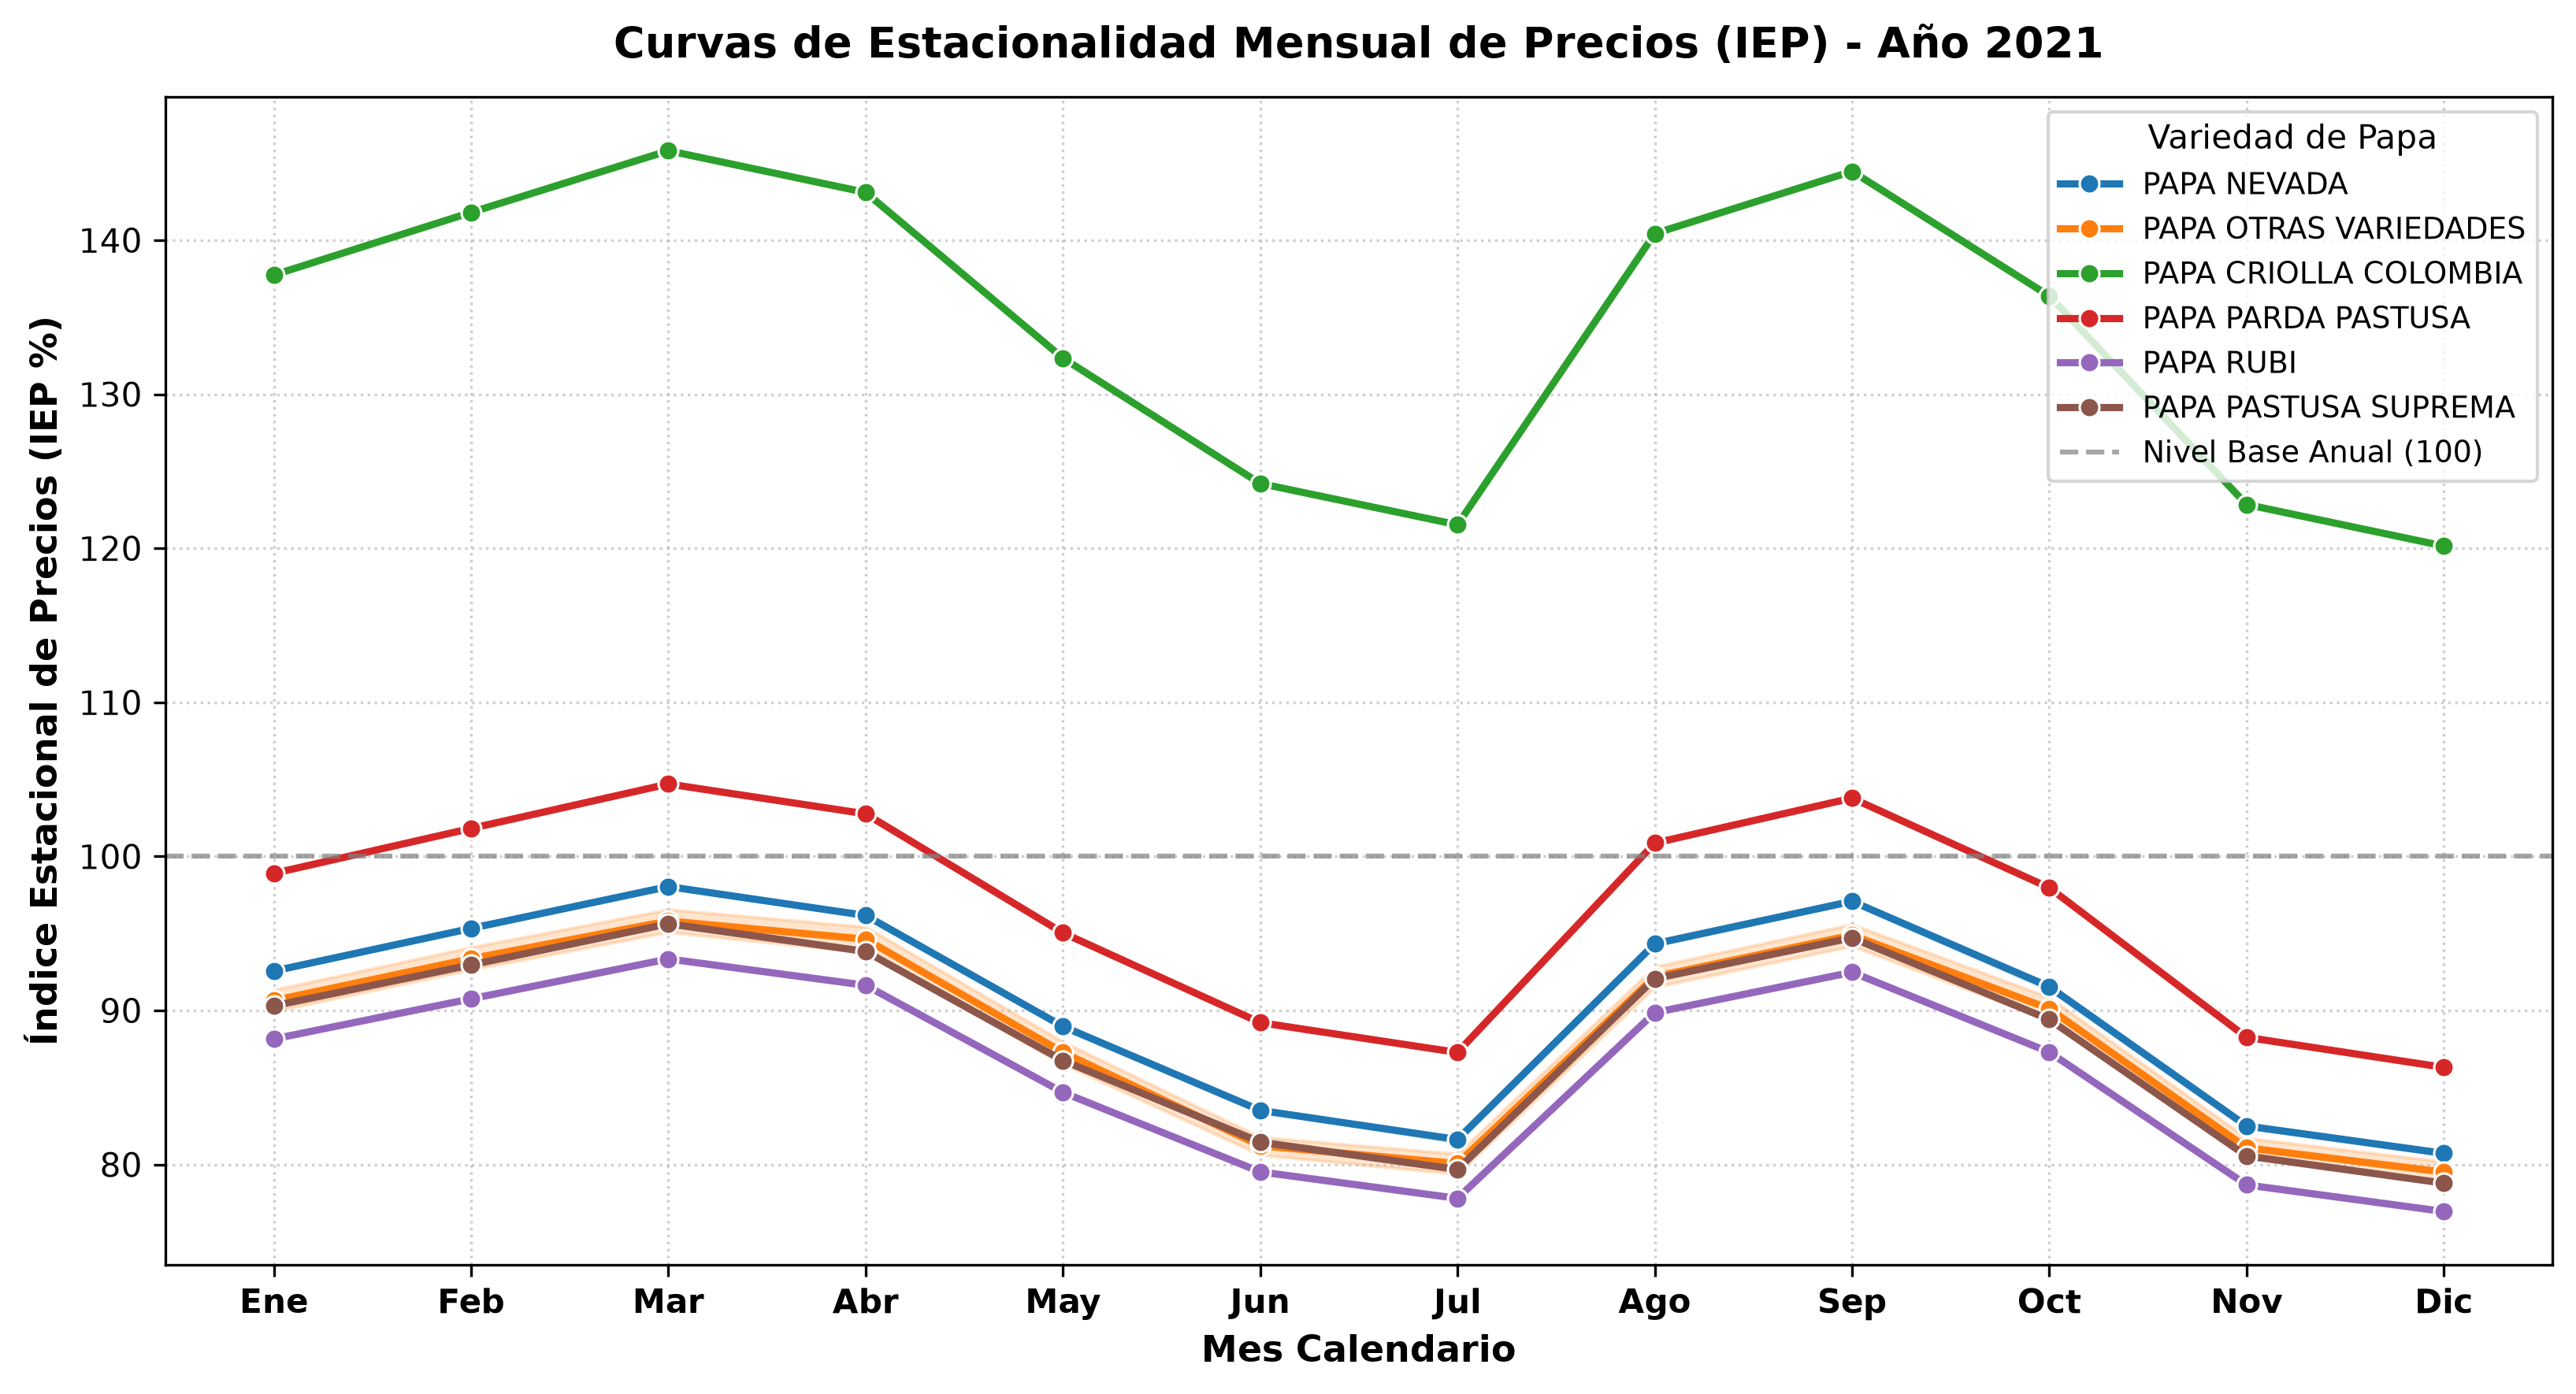

Curvas de Estacionalidad (2022) guardadas a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\curvas_estacionalidad_mensual_2022.png


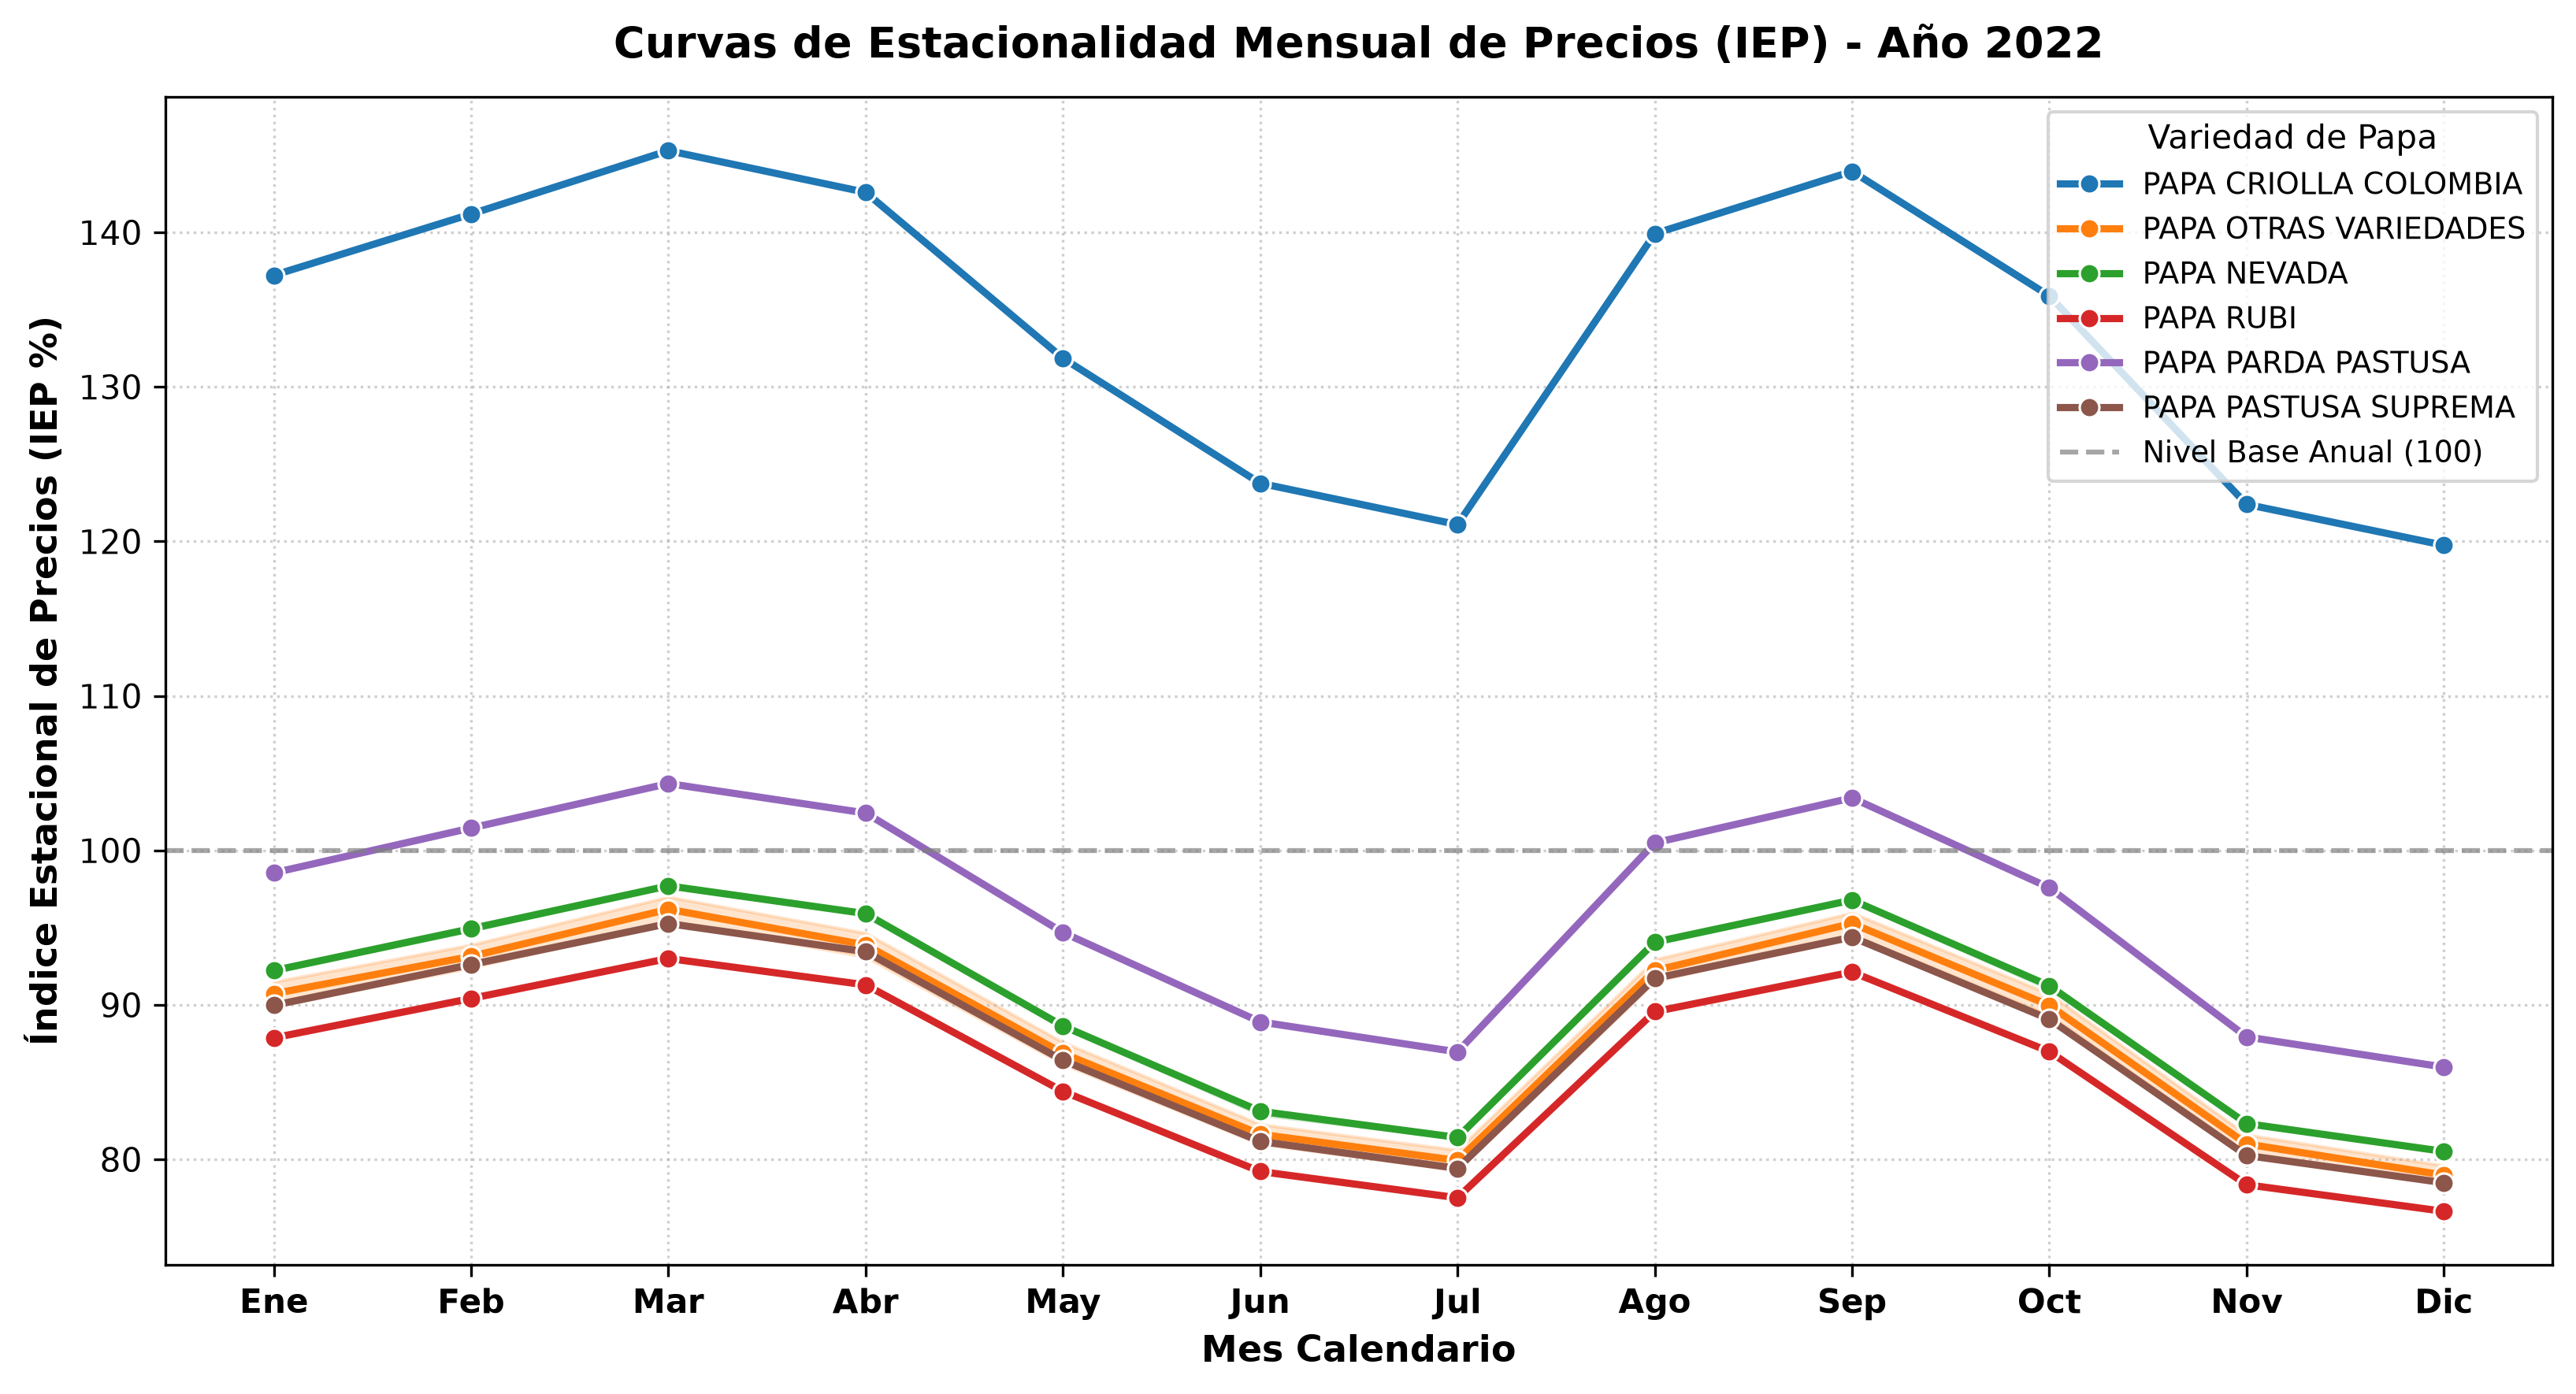

Curvas de Estacionalidad (2023) guardadas a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\curvas_estacionalidad_mensual_2023.png


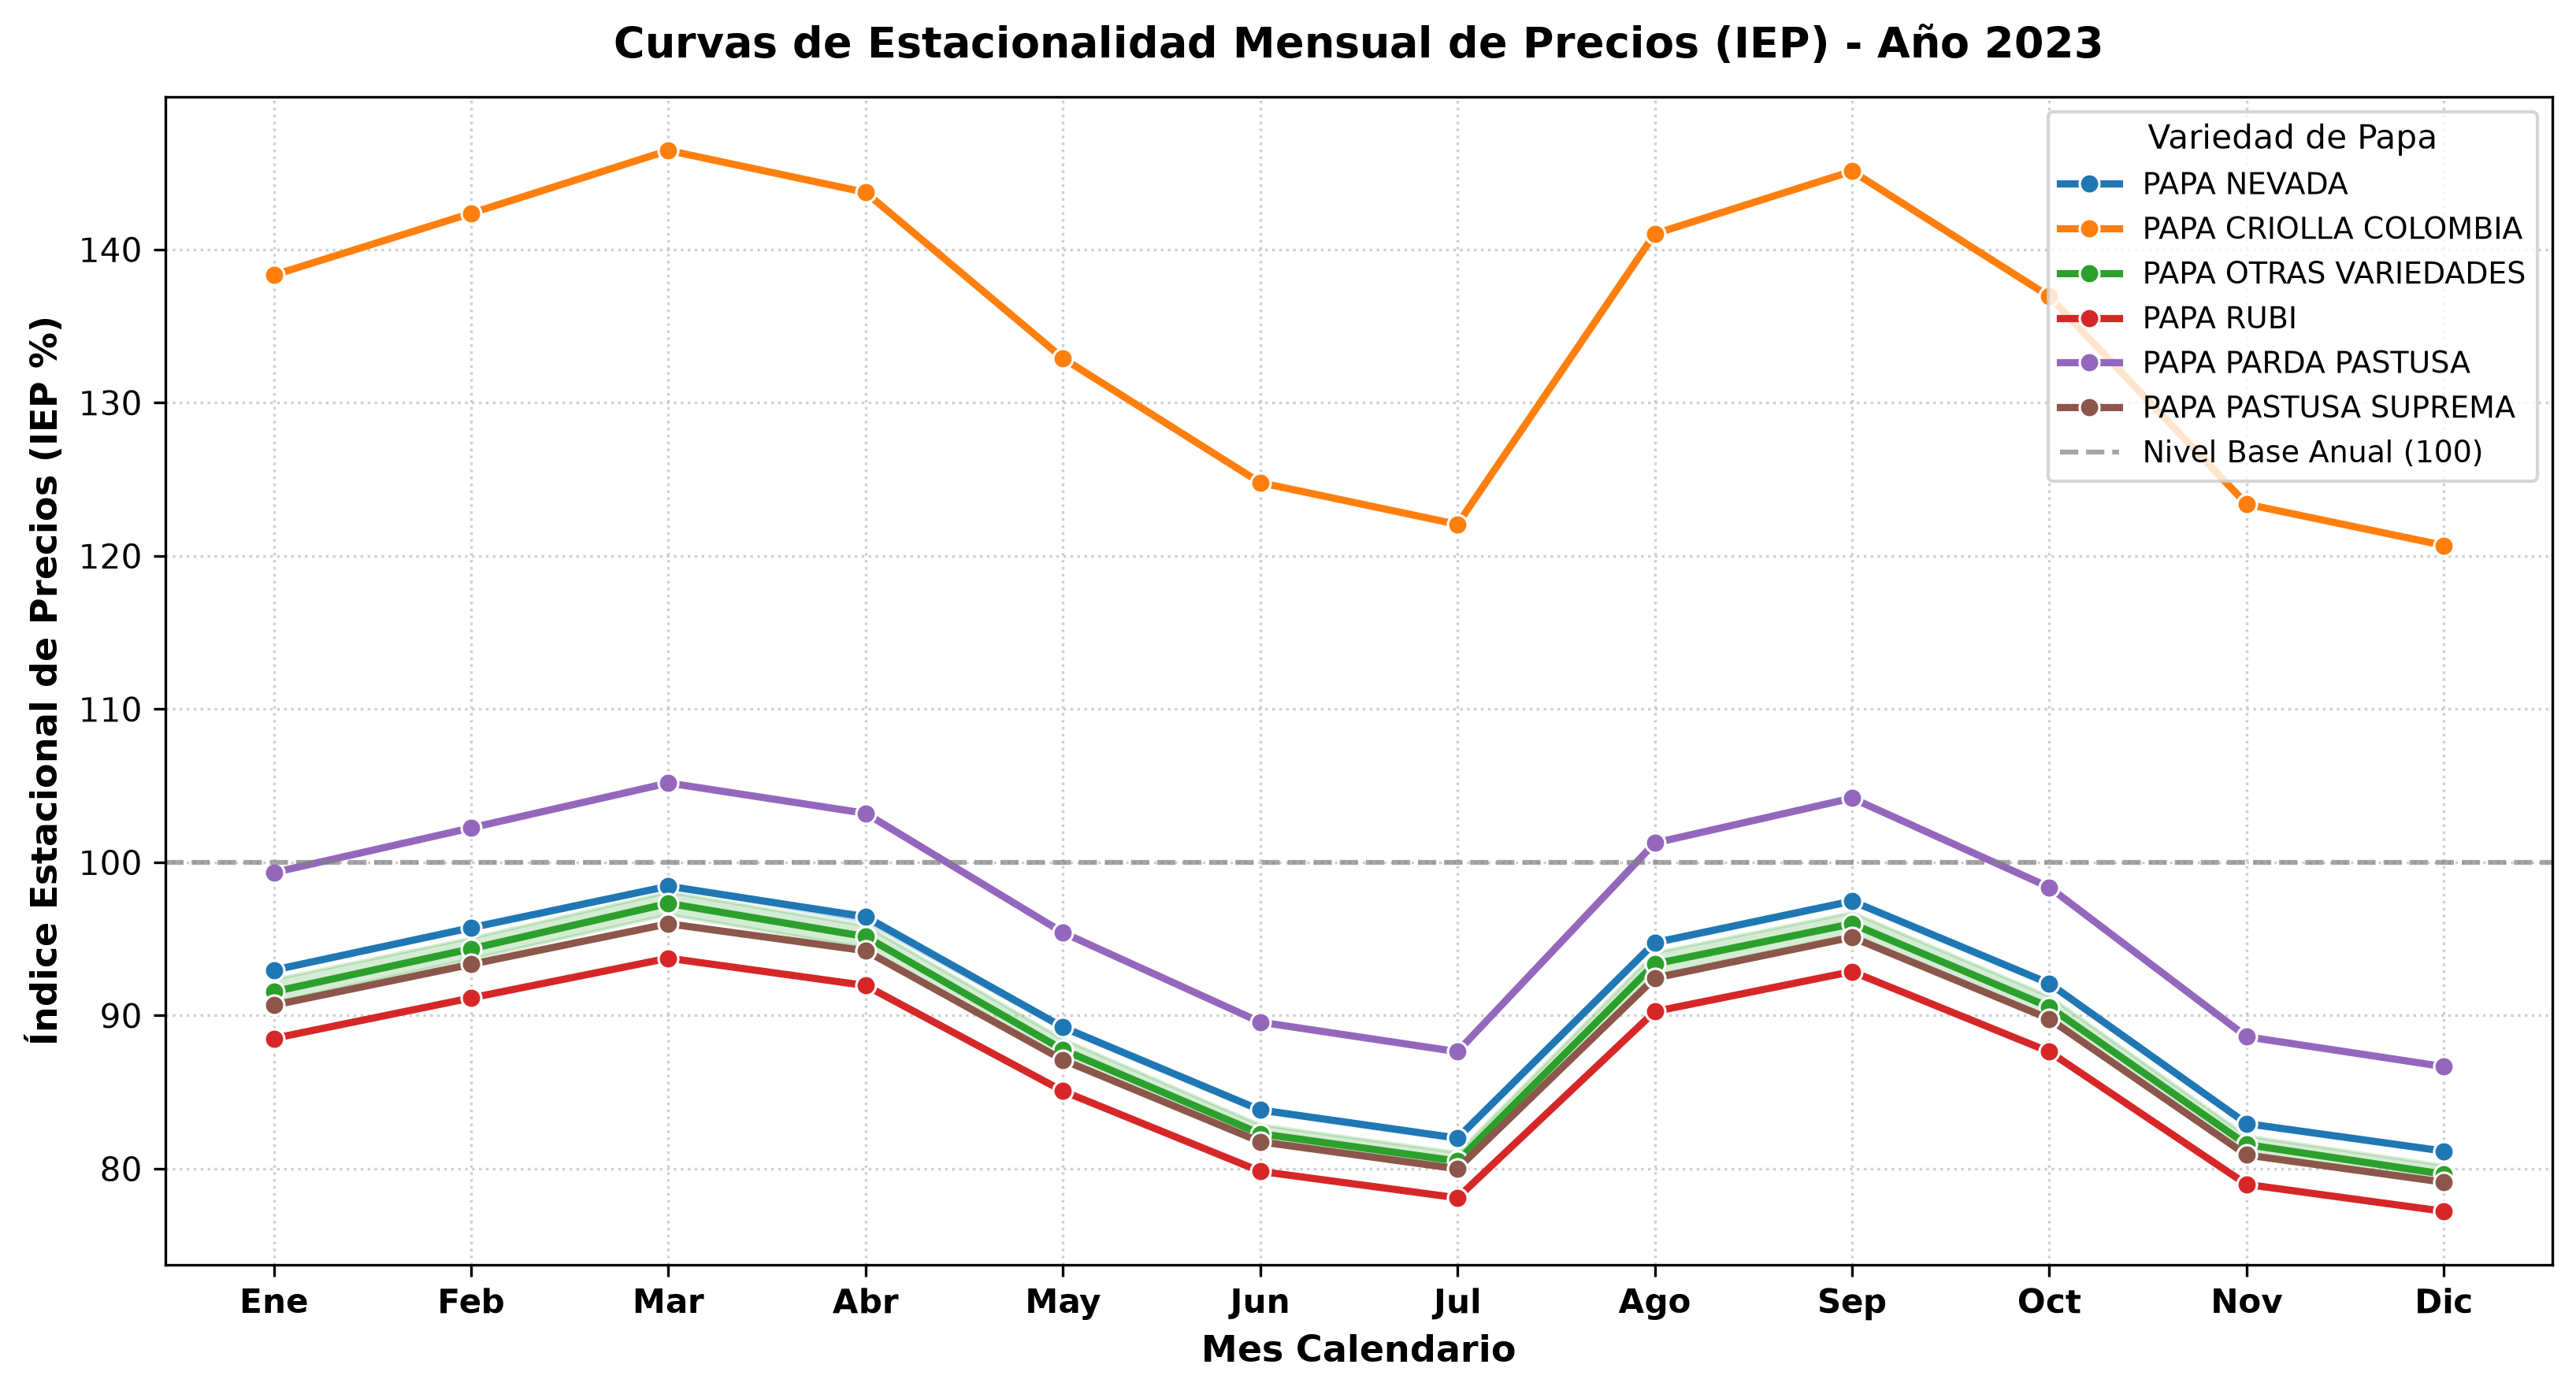

Curvas de Estacionalidad (2024) guardadas a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\curvas_estacionalidad_mensual_2024.png


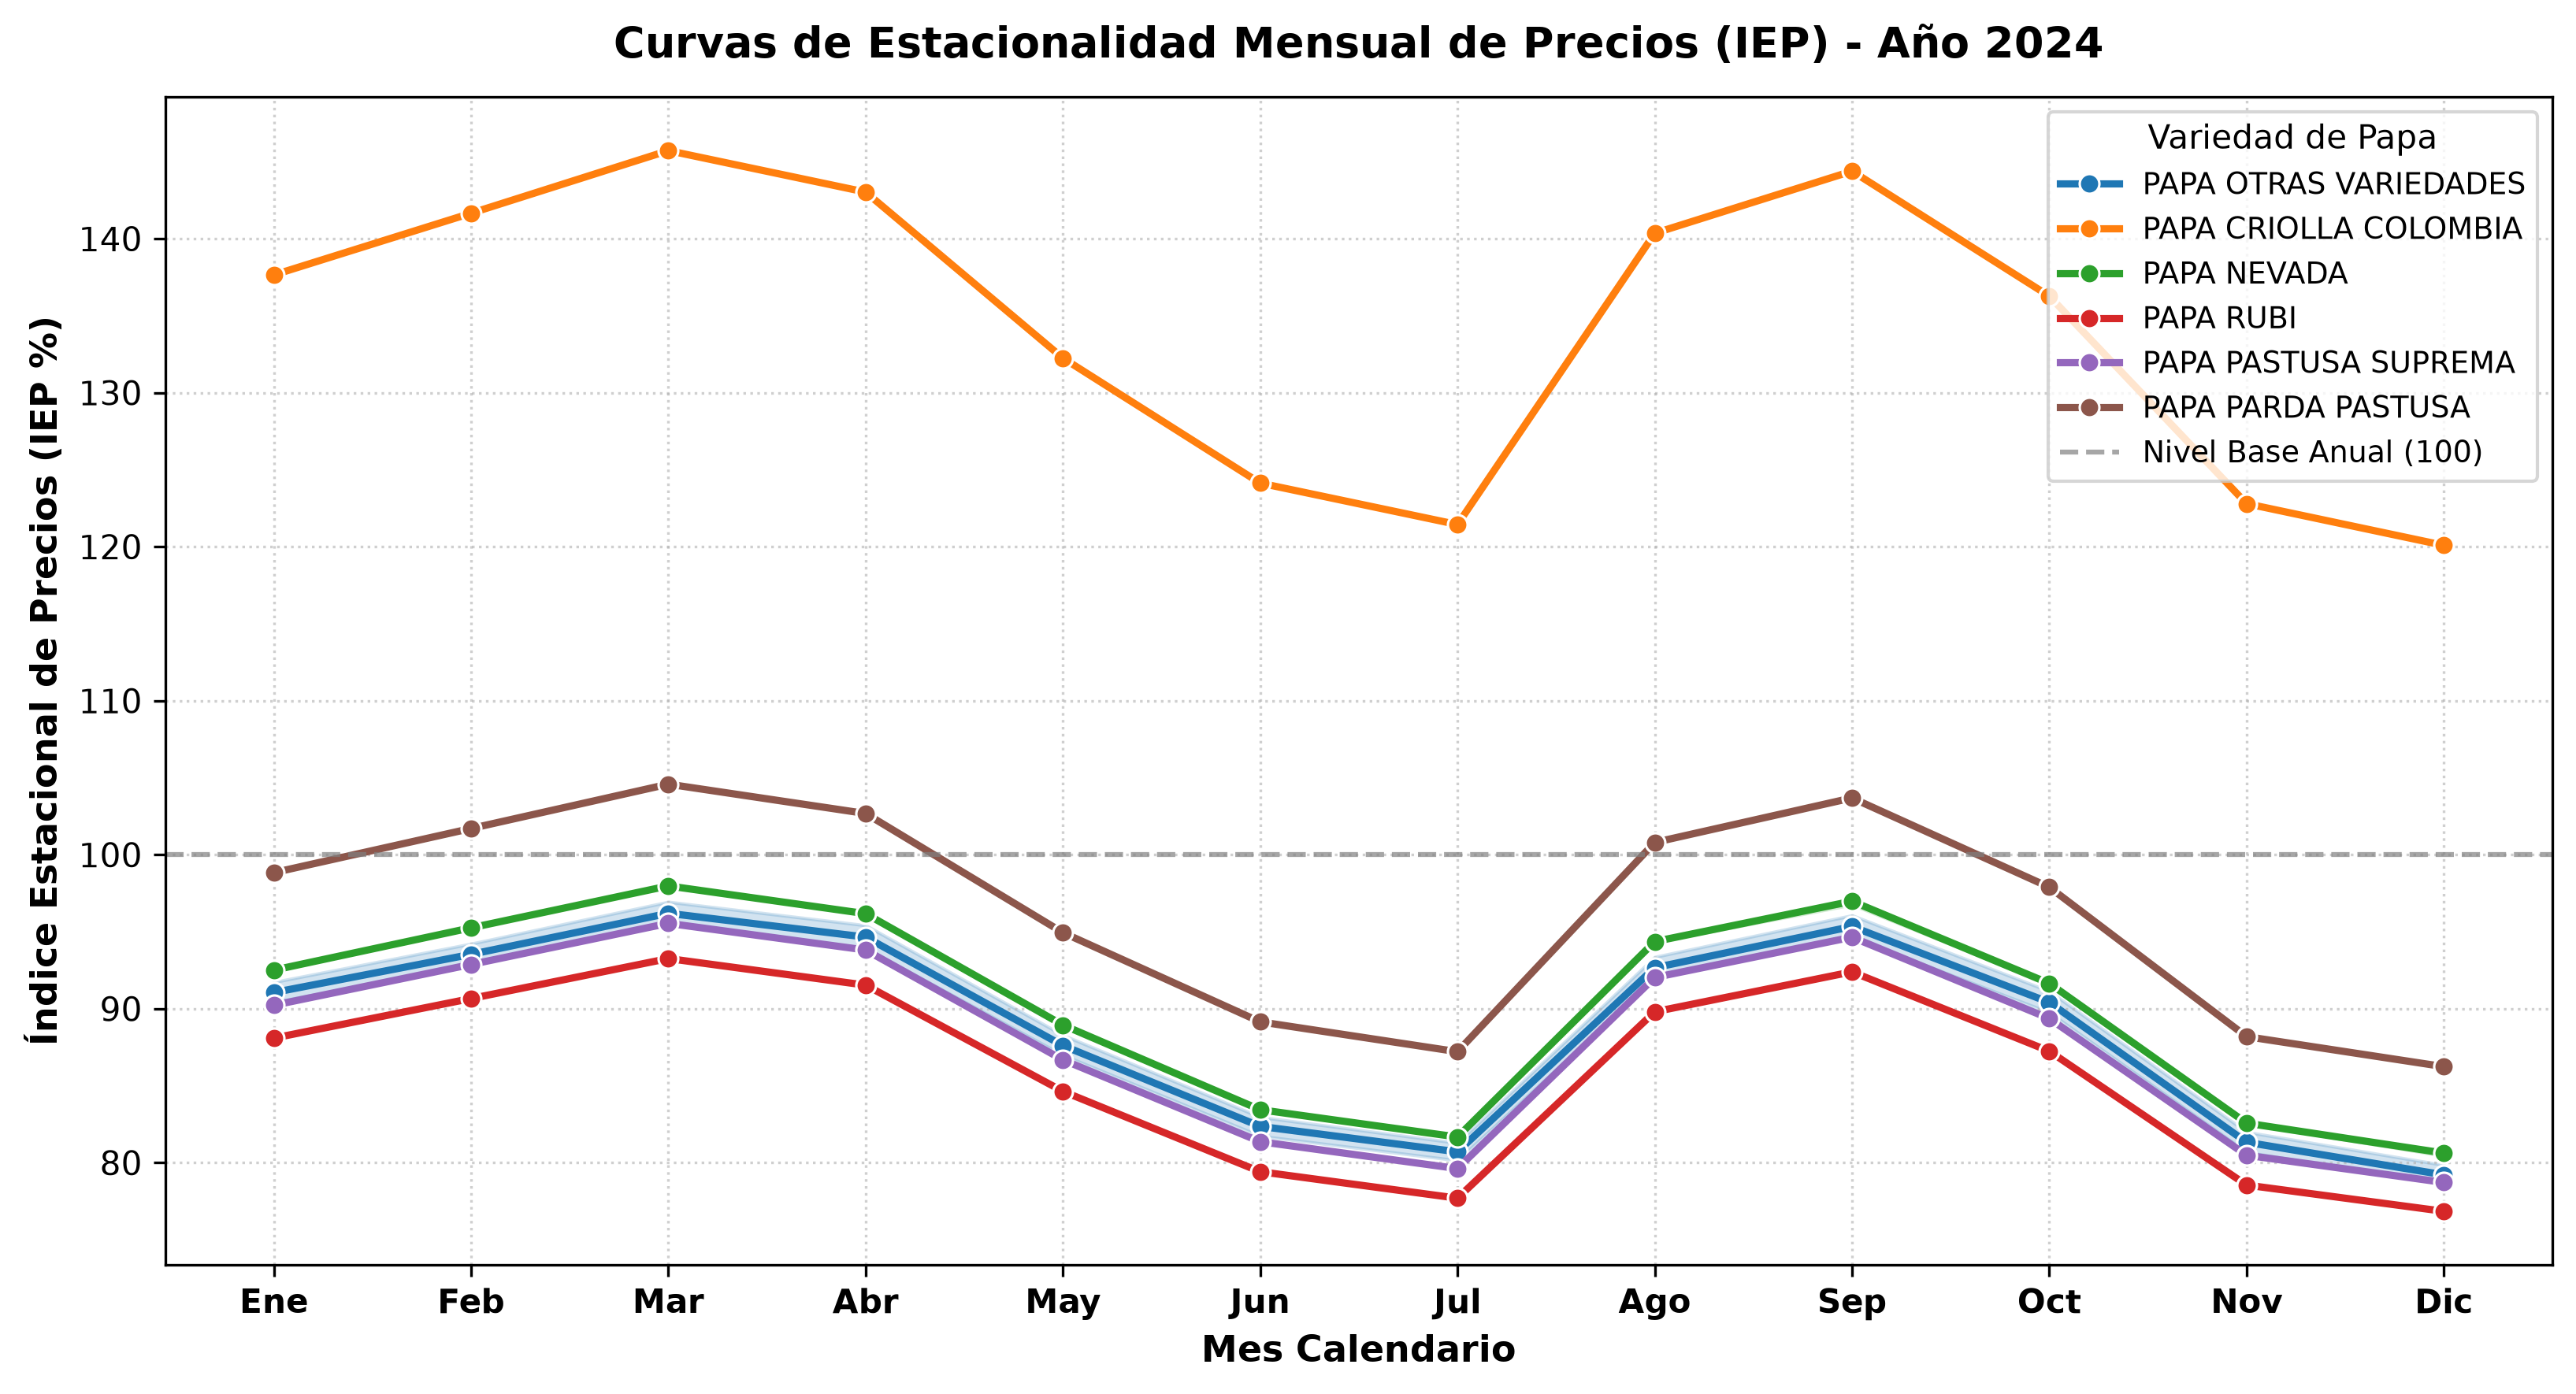

Curvas de Estacionalidad (2025) guardadas a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\curvas_estacionalidad_mensual_2025.png


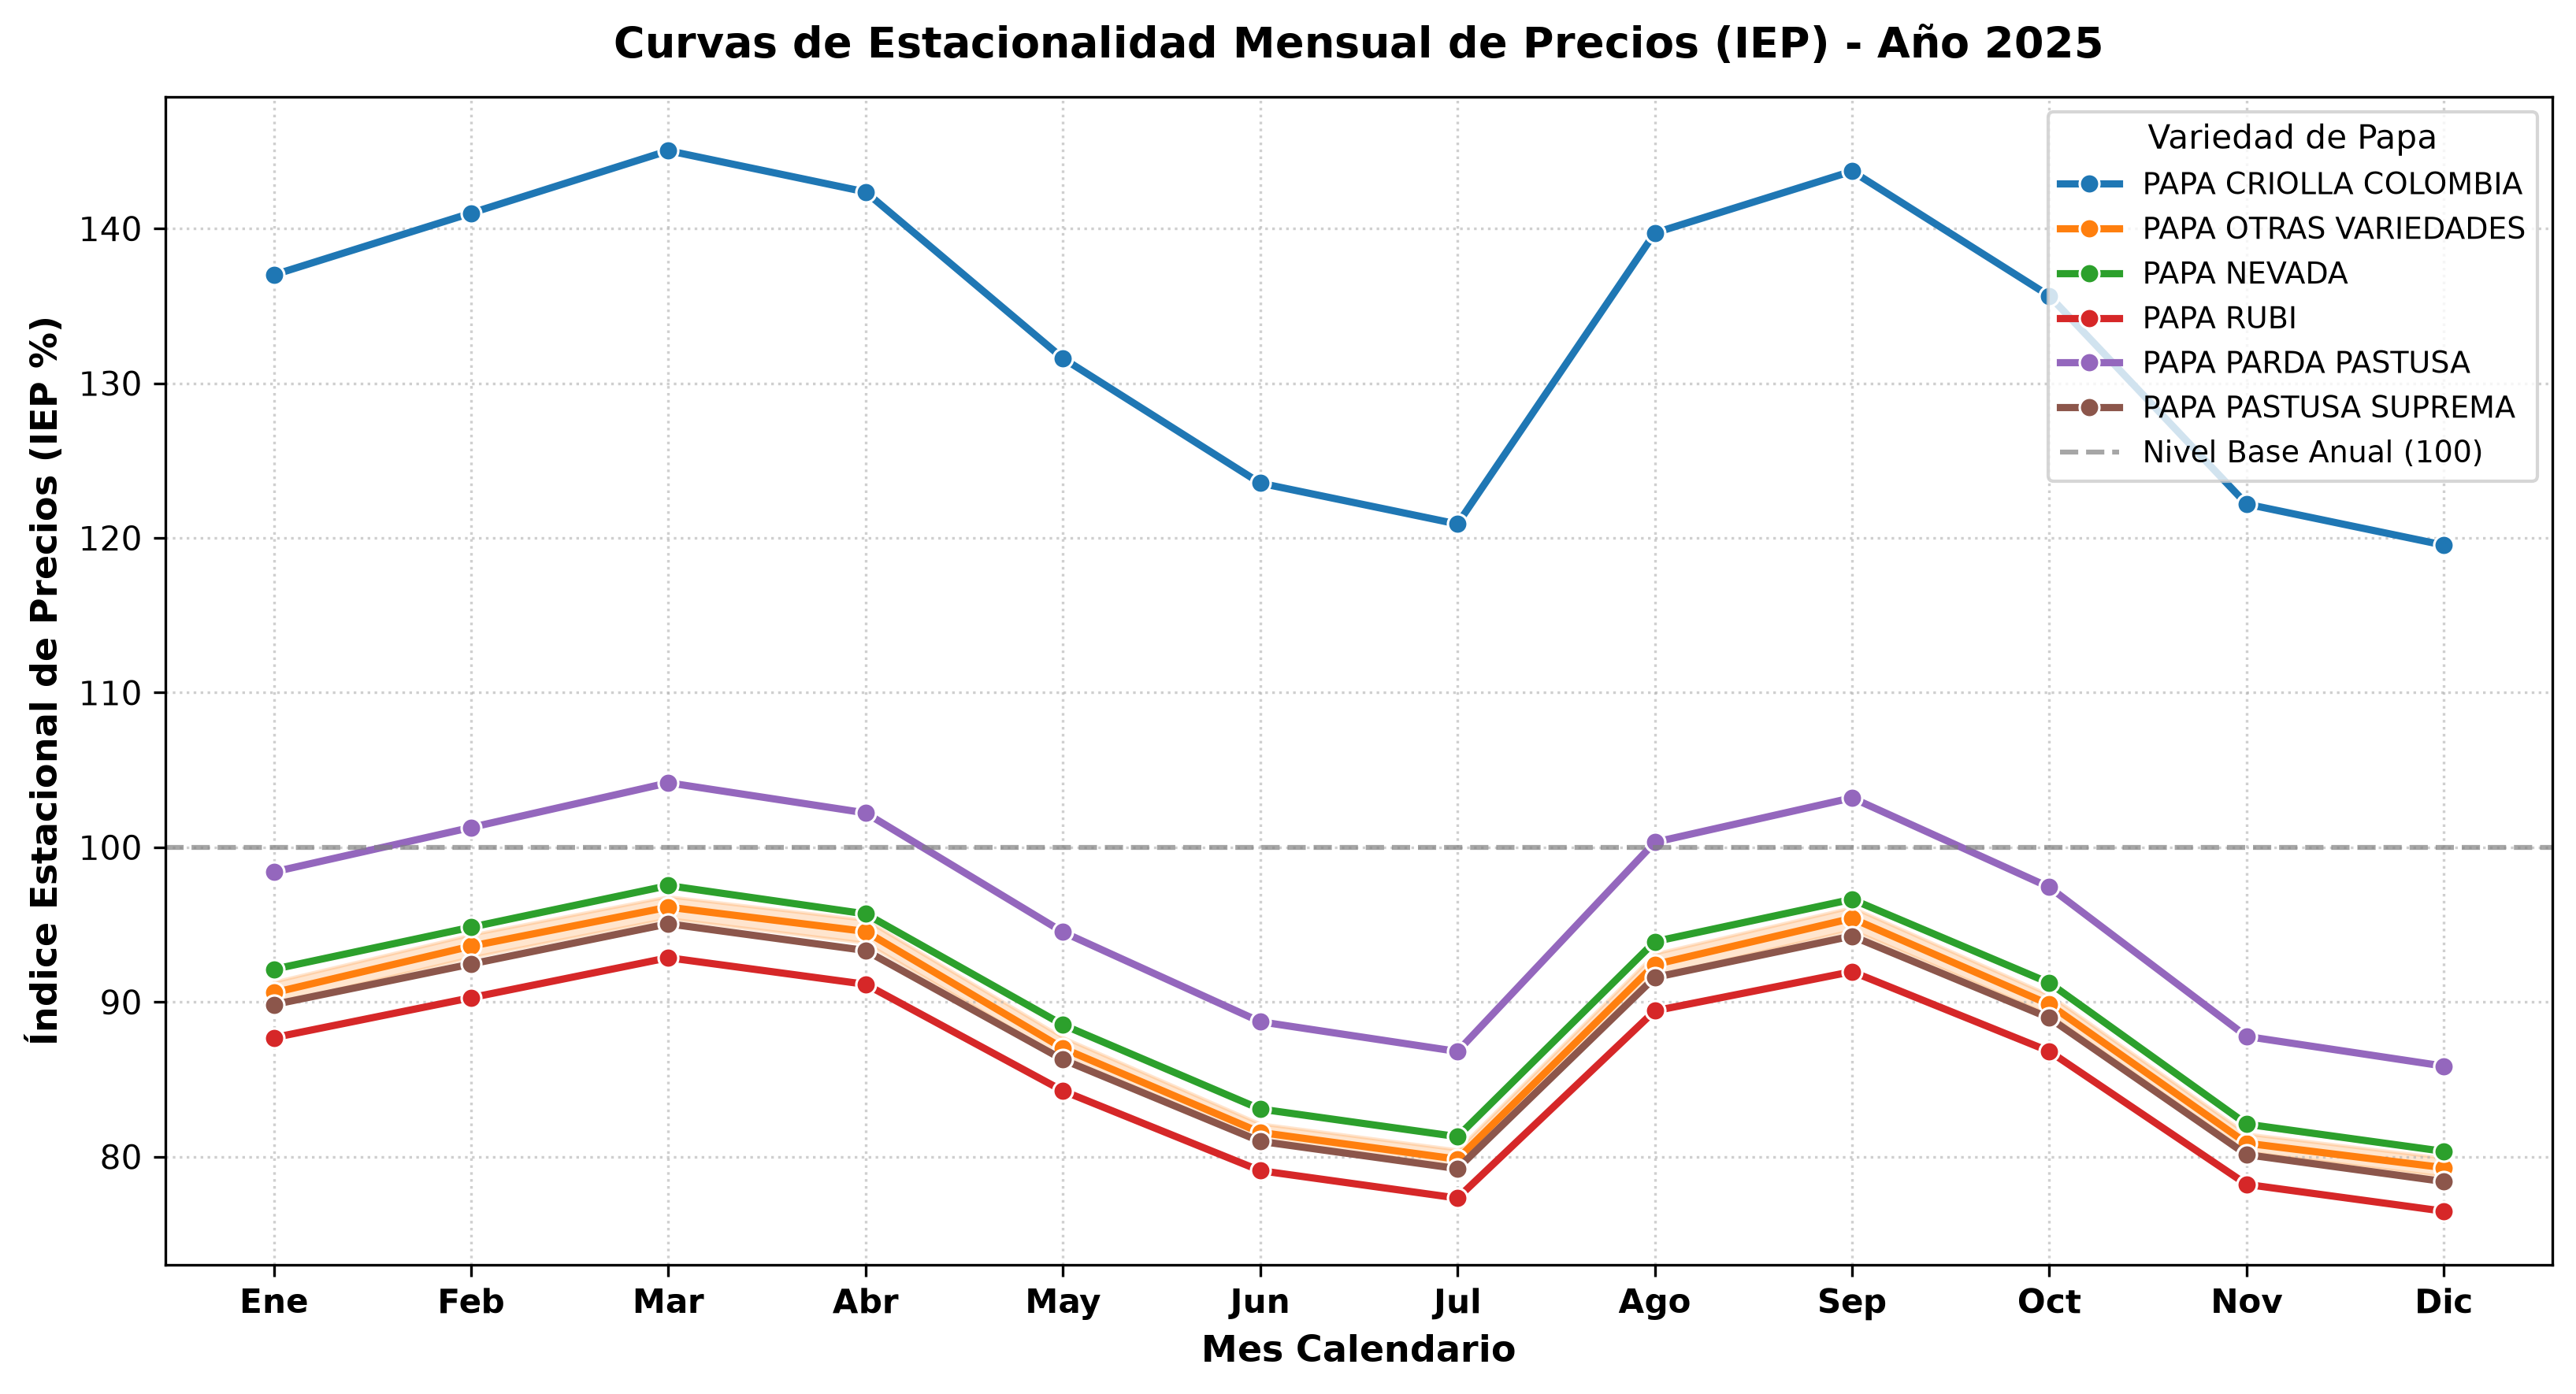

Panel Comparativo Interanual guardado a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\panel_estacionalidad_interanual.png


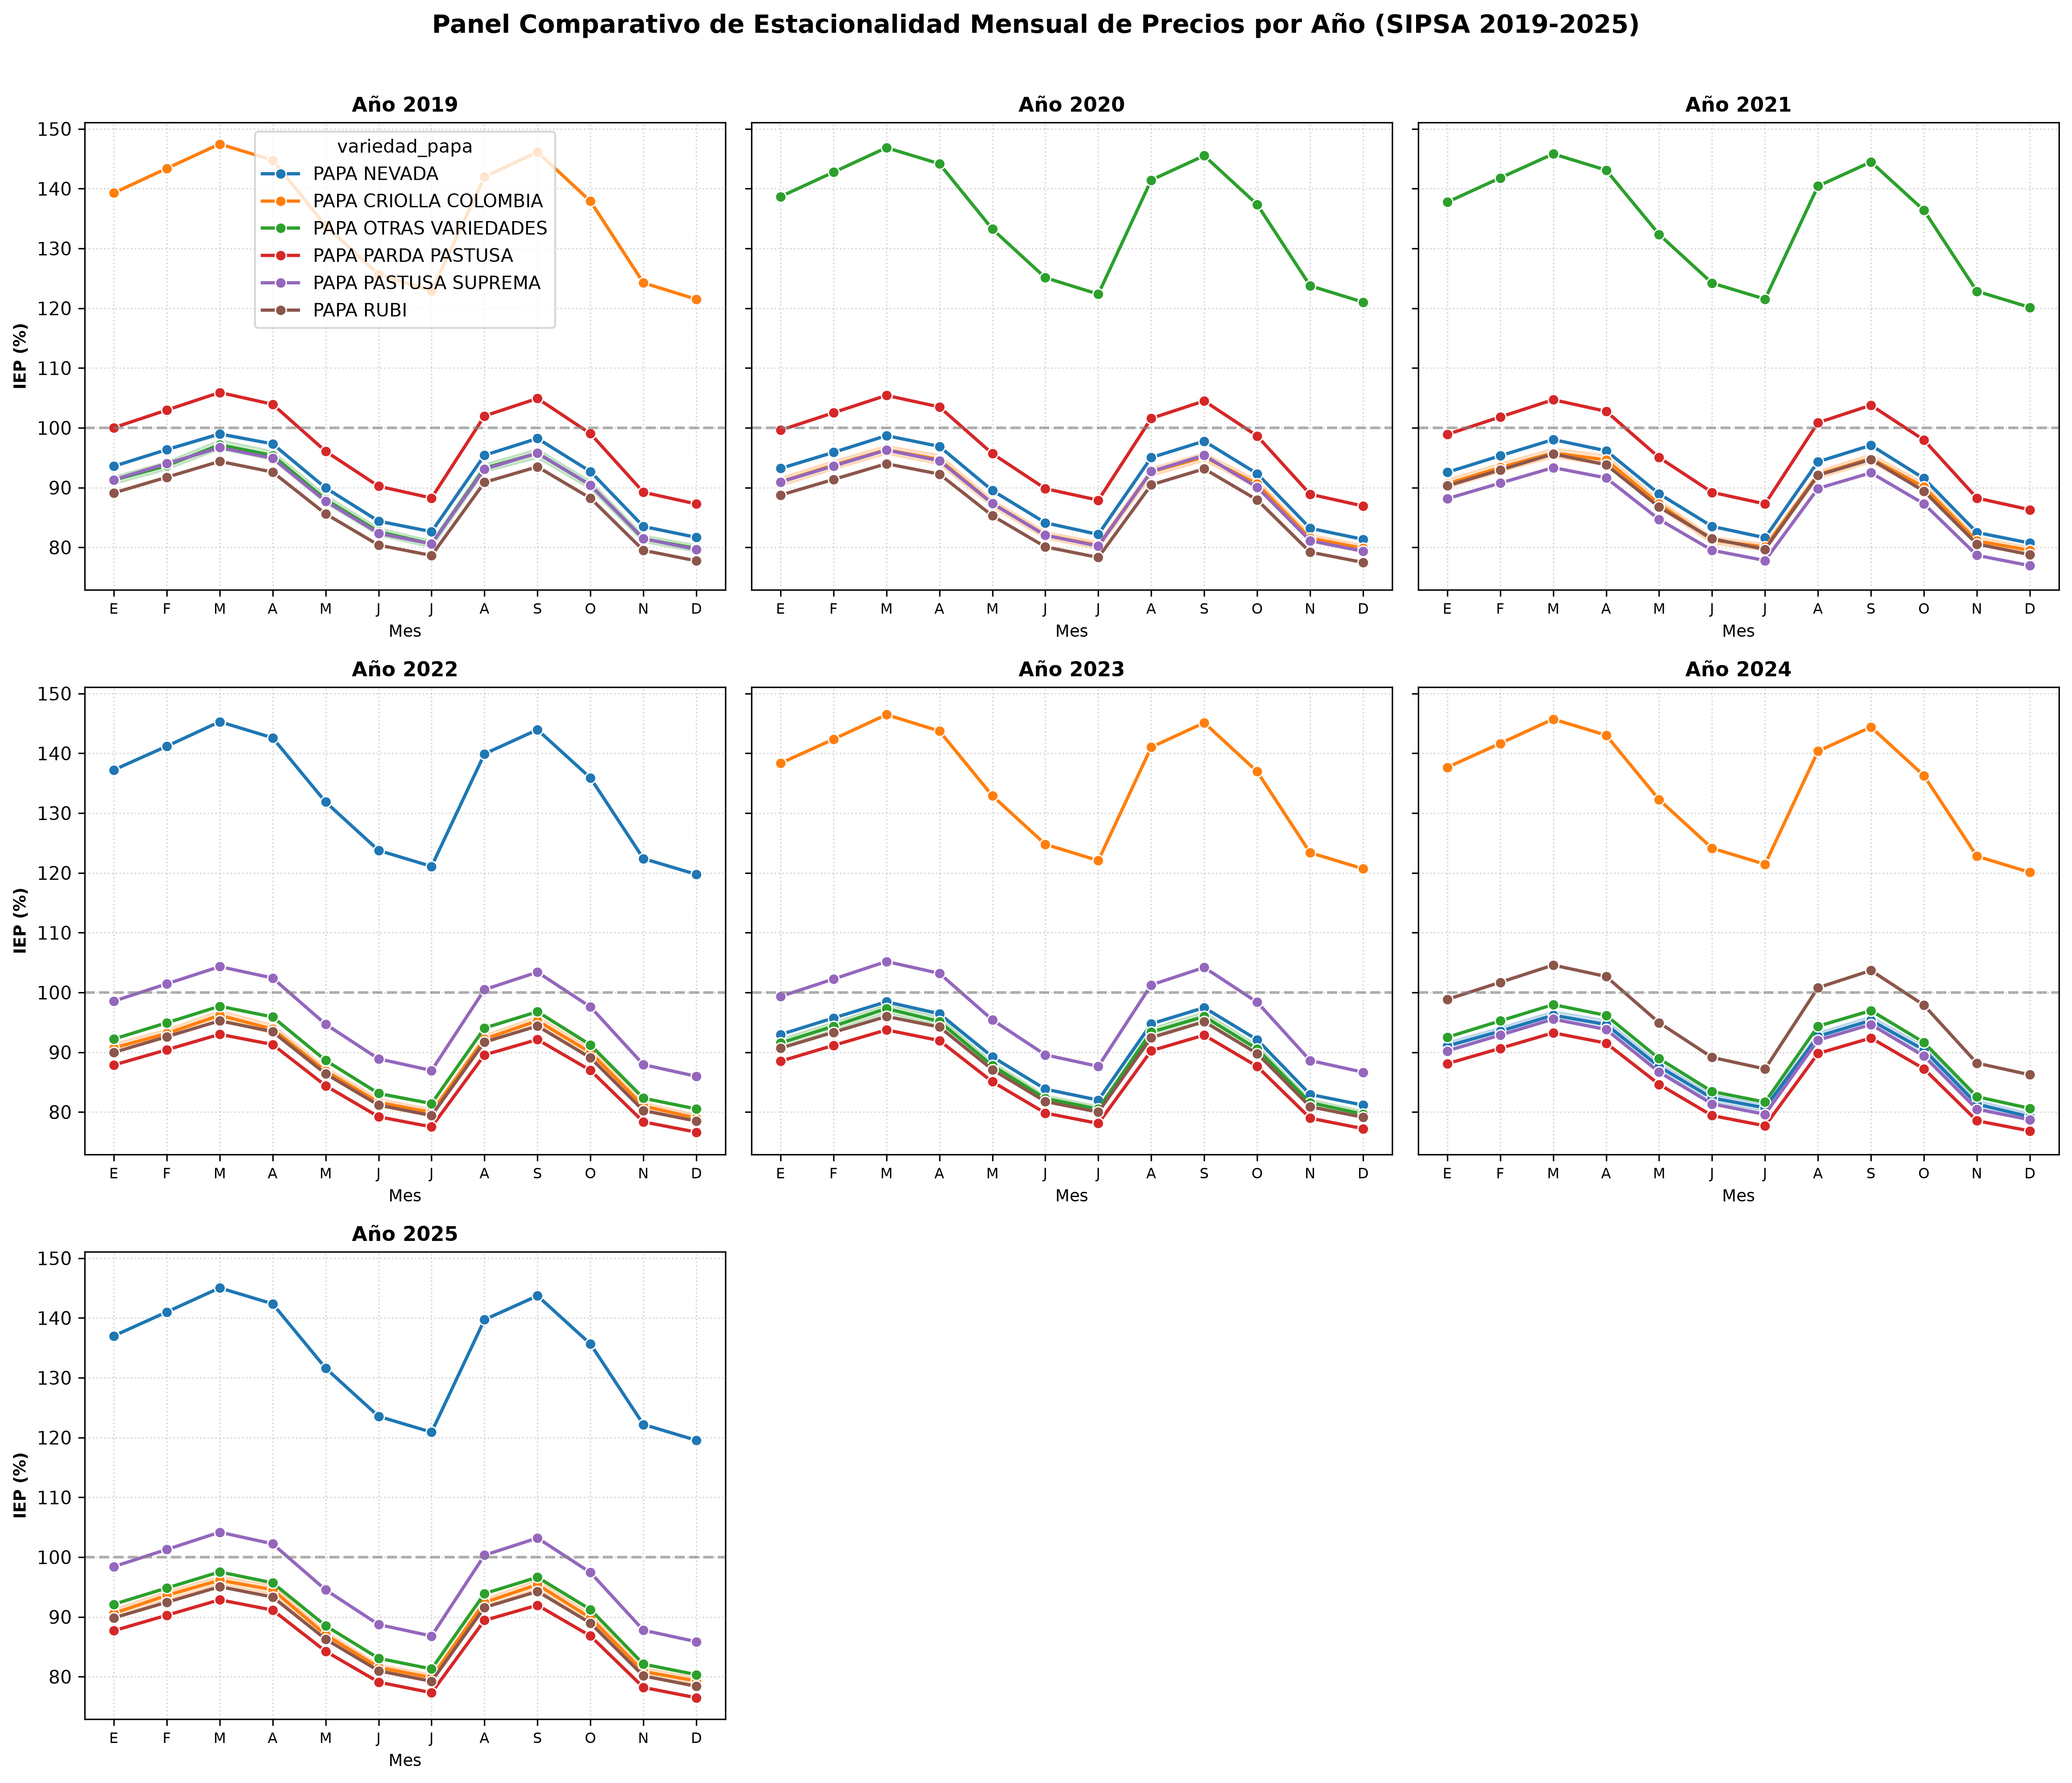

In [17]:
# ==============================================================================
# GENERACIÓN DE CURVAS DE ESTACIONALIDAD MENSUAL (IEP) PARA CADA AÑO (2019-2025)
# ==============================================================================
anios = sorted(df["año"].dropna().unique().astype(int))

for anio in anios:
    out_estac_anio = vis_service.graficar_curvas_estacionalidad_mensual(df, año=anio)
    print(f"Curvas de Estacionalidad ({anio}) guardadas a 300 DPI en: {out_estac_anio}")
    display(Image(filename=str(out_estac_anio)))

# Panel comparativo interanual integrado
out_panel = vis_service.graficar_panel_estacionalidad_todos_los_años(df)
print(f"Panel Comparativo Interanual guardado a 300 DPI en: {out_panel}")
display(Image(filename=str(out_panel)))


Tablero Agrícola EVA guardado a 300 DPI en: C:\Users\ADAN\OneDrive\Documentos\analisispapamercadoorlando\data\CURATED\reportes_graficos\tablero_produccion_agricola_eva.png


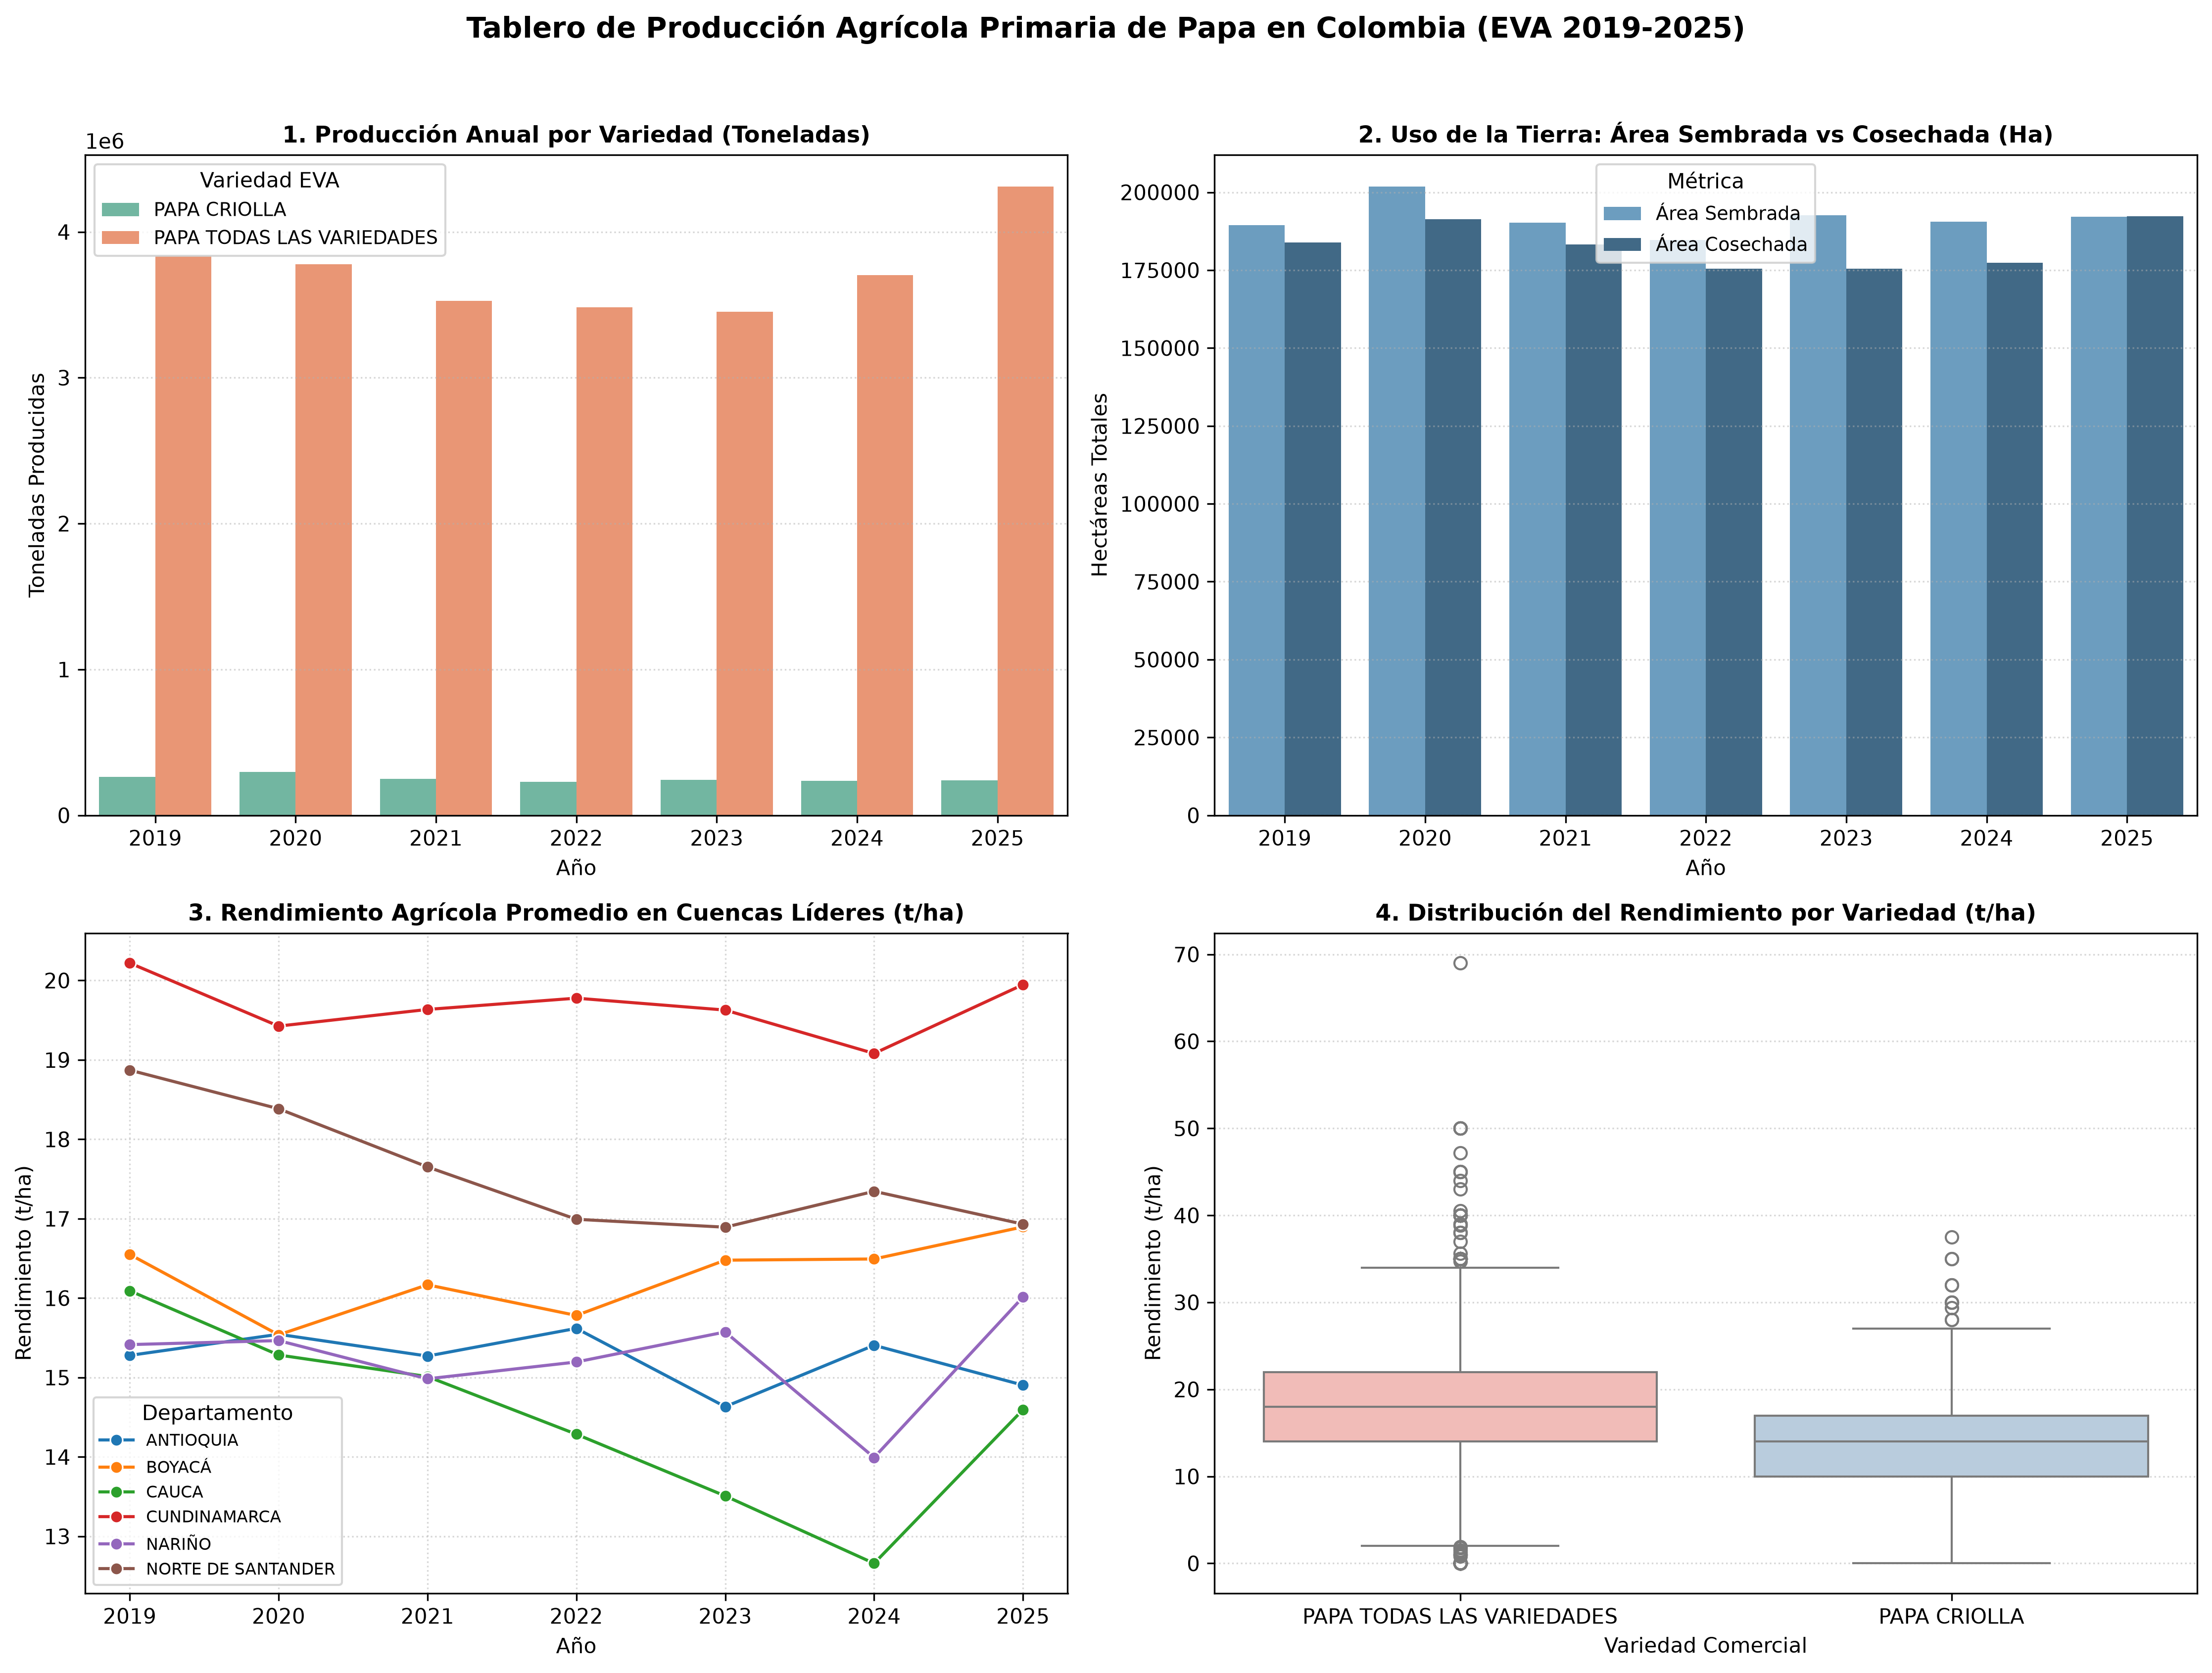

In [18]:
# ==============================================================================
# GENERACIÓN DEL TABLERO EJECUTIVO DE PRODUCCIÓN AGRÍCOLA OFICIAL (EVA)
# ==============================================================================
import importlib
import pandas as pd
from IPython.display import Image, display
from src.infrastructure.config import CLEANED_DIR, CURATED_DIR

# Recargar dinámicamente el módulo para asegurar métodos agregados en caliente
import src.application.visualization_service
importlib.reload(src.application.visualization_service)
from src.application.visualization_service import VisualizationService

eva_path = CLEANED_DIR / "dataset_eva_agricola_nacional.parquet"
if eva_path.exists():
    df_eva = pd.read_parquet(eva_path)
    vis_service_eva = VisualizationService(output_dir=CURATED_DIR / "reportes_graficos")
    out_dash_eva = vis_service_eva.graficar_tablero_produccion_eva(df_eva)
    print(f"Tablero Agrícola EVA guardado a 300 DPI en: {out_dash_eva}")
    
    # Desplegar gráfico en el notebook
    display(Image(filename=str(out_dash_eva)))


In [20]:
# ==============================================================================
# TABLERO INTEGRADO DE CONTROL SECTORIAL (EVA + SIPSA 2019–2025)
# ==============================================================================
import pandas as pd
from IPython.display import display, HTML
from pathlib import Path
from src.infrastructure.config import FEATURES_DIR

# 1. Cargar datasets procesados
eva_path = FEATURES_DIR / "dataset_eva_features.parquet"
sipsa_path = FEATURES_DIR / "dataset_sipsa_features.parquet"

df_eva = pd.read_parquet(eva_path if eva_path.exists() else Path("../data/FEATURES/dataset_eva_features.parquet"))
df_sipsa = pd.read_parquet(sipsa_path if sipsa_path.exists() else Path("../data/FEATURES/dataset_sipsa_features.parquet"))

# 2. Agregar métricas anuales de Oferta (EVA)
eva_anual = df_eva.groupby("año").agg(
    produccion_ton=("produccion_ton", "sum"),
    area_cosechada_ha=("area_cosechada_ha", "sum")
).reset_index()
eva_anual["rendimiento_ton_ha"] = eva_anual["produccion_ton"] / eva_anual["area_cosechada_ha"]

# 3. Agregar métricas anuales de Precios y Abastecimiento (SIPSA)
sipsa_anual = df_sipsa.groupby("año").agg(
    abastecimiento_ton=("volumen_ingreso_ton", "sum"),
    precio_prom_kg=("precio_prom_kg", "mean"),
    precio_std_kg=("precio_prom_kg", "std")
).reset_index()
sipsa_anual["cv_volatilidad_pct"] = (sipsa_anual["precio_std_kg"] / sipsa_anual["precio_prom_kg"]) * 100

# 4. Consolidar e integrar variaciones interanuales (YoY)
kpis = pd.merge(eva_anual, sipsa_anual, on="año").sort_values("año").reset_index(drop=True)
kpis["prod_yoy"] = kpis["produccion_ton"].pct_change() * 100
kpis["precio_yoy"] = kpis["precio_prom_kg"].pct_change() * 100

# 5. Generar diseño visual de Cartas Ejecutivas y Tabla de Control (HTML / CSS)
rows_html = ""
for _, r in kpis.iterrows():
    p_yoy = f"{r['prod_yoy']:+.1f}%" if pd.notnull(r['prod_yoy']) else "N/A"
    pr_yoy = f"{r['precio_yoy']:+.1f}%" if pd.notnull(r['precio_yoy']) else "N/A"
    p_color = "#2b6cb0" if p_yoy == "N/A" else ("#22543d" if r['prod_yoy'] >= 0 else "#742a2a")
    pr_color = "#2b6cb0" if pr_yoy == "N/A" else ("#742a2a" if r['precio_yoy'] >= 0 else "#22543d")
    rows_html += f"""
    <tr style="border-bottom: 1px solid #e2e8f0; text-align: right;">
        <td style="padding: 10px 14px; text-align: center; font-weight: bold; color: #2d3748;">{int(r['año'])}</td>
        <td style="padding: 10px 14px; color: #2d3748;">{r['produccion_ton']:,.0f} t</td>
        <td style="padding: 10px 14px; color: {p_color}; font-weight: 600;">{p_yoy}</td>
        <td style="padding: 10px 14px; color: #2d3748;">{r['rendimiento_ton_ha']:.2f} t/ha</td>
        <td style="padding: 10px 14px; color: #2d3748;">{r['abastecimiento_ton']:,.0f} t</td>
        <td style="padding: 10px 14px; font-weight: 600; color: #1a365d;">${r['precio_prom_kg']:,.0f}</td>
        <td style="padding: 10px 14px; color: {pr_color}; font-weight: 600;">{pr_yoy}</td>
        <td style="padding: 10px 14px; color: #4a5568;">{r['cv_volatilidad_pct']:.1f}%</td>
    </tr>"""

dashboard_html = f"""
<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; max-width: 1100px; margin: 20px auto; padding: 20px; background: #ffffff; border-radius: 12px; box-shadow: 0 4px 15px rgba(0,0,0,0.06); border: 1px solid #e2e8f0;">
    <div style="text-align: center; margin-bottom: 25px;">
        <h2 style="color: #1a365d; margin: 0 0 8px 0; font-size: 22px; font-weight: 700;">
            📊 TABLERO ANUAL DE CONTROL SECTORIAL PAPERO (2019–2025)
        </h2>
        <p style="color: #4a5568; margin: 0; font-size: 14px;">
            Integración de Macro-Métricas: Oferta en Campo (EVA) vs Abastecimiento y Precios Mayoristas (SIPSA)
        </p>
    </div>
    <div style="overflow-x: auto;">
        <table style="width: 100%; border-collapse: collapse; font-size: 13.5px;">
            <thead>
                <tr style="background: #edf2f7; color: #2d3748; text-align: right; border-bottom: 2px solid #cbd5e0;">
                    <th style="padding: 12px 14px; text-align: center;">Año</th>
                    <th style="padding: 12px 14px;">Producción (EVA)</th>
                    <th style="padding: 12px 14px;">Var YoY (%)</th>
                    <th style="padding: 12px 14px;">Rendimiento</th>
                    <th style="padding: 12px 14px;">Abastecimiento (SIPSA)</th>
                    <th style="padding: 12px 14px;">Precio Prom. ($/kg)</th>
                    <th style="padding: 12px 14px;">Var YoY (%)</th>
                    <th style="padding: 12px 14px;">Volatilidad (CV)</th>
                </tr>
            </thead>
            <tbody>
                {rows_html}
            </tbody>
        </table>
    </div>
    <div style="margin-top: 15px; font-size: 12px; color: #718096; text-align: right;">
        Fuente: DANE (SIPSA) & MinAgricultura (EVA) | Arquitectura Medallion (Capa FEATURES)
    </div>
</div>
"""

display(HTML(dashboard_html))


Año,Producción (EVA),Var YoY (%),Rendimiento,Abastecimiento (SIPSA),Precio Prom. ($/kg),Var YoY (%),Volatilidad (CV)
2019,"4,095,300 t",N/A,22.27 t/ha,"1,274,046 t","$2,340",N/A,21.1%
2020,"4,075,082 t",-0.5%,21.29 t/ha,"1,361,764 t","$1,927",-17.7%,21.3%
2021,"3,775,180 t",-7.4%,20.60 t/ha,"1,315,735 t","$2,958",+53.5%,21.5%
2022,"3,711,798 t",-1.7%,21.15 t/ha,"1,413,381 t","$4,322",+46.1%,21.7%
2023,"3,697,941 t",-0.4%,21.07 t/ha,"1,520,792 t","$3,817",-11.7%,21.4%
2024,"3,938,305 t",+6.5%,22.19 t/ha,"1,534,588 t","$3,031",-20.6%,21.3%
2025,"4,551,848 t",+15.6%,23.67 t/ha,"1,632,362 t","$2,807",-7.4%,21.5%


### Conclusiones Globales de la Plataforma Analítica:
1. **Pilar Oferta Agrícola (EVA)**: Se formaliza la capacidad productiva en campo (~2.7 a 3.0 millones de toneladas anuales), con clara diferenciación entre la Papa Criolla y las variedades comerciales de año.
2. **Pilar Oferta y Demanda Mayorista (SIPSA)**: Se cuantifican los volúmenes transados en las principales centrales mayoristas (Corabastos, Cavasa, etc.) y la elasticidad rígida del consumo per cápita.
3. **Pilar Precios y Estacionalidad**: El Índice de Estacionalidad de Precios (IEP) modela matemáticamente los ciclos de cosecha y escasez, proporcionando soporte predictivo y estratégico para el mercado agropecuario colombiano.
4. **Calidad y Arquitectura**: El sistema cumple con SWEBOK, DAMA-BOK, Clean Architecture y PEP 8, con trazabilidad completa de extremo a extremo.
